In [3]:
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.timeseries import LombScargle

def _bin_series_fixed_width(x, y, width):
    if not np.isfinite(width) or width <= 0:
        return np.array([]), np.array([])
    x_arr = np.asarray(x, dtype=float)
    y_arr = np.asarray(y, dtype=float)
    mask = np.isfinite(x_arr) & np.isfinite(y_arr)
    if not mask.any():
        return np.array([]), np.array([])
    x_valid = x_arr[mask]
    y_valid = y_arr[mask]
    x_min = np.nanmin(x_valid)
    x_max = np.nanmax(x_valid)
    if not np.isfinite(x_min) or not np.isfinite(x_max):
        return np.array([]), np.array([])
    if x_min == x_max:
        edges = np.array([x_min, x_min + width])
    else:
        edges = np.arange(x_min, x_max + width, width)
        if edges.size < 2:
            edges = np.array([x_min, x_max])
    return _bin_series_by_edges(x_valid, y_valid, edges)

def _bin_series_by_edges(x, y, edges):
    x_arr = np.asarray(x, dtype=float)
    y_arr = np.asarray(y, dtype=float)
    mask = np.isfinite(x_arr) & np.isfinite(y_arr)
    if not mask.any():
        return np.array([]), np.array([])
    x_valid = x_arr[mask]
    y_valid = y_arr[mask]
    inds = np.digitize(x_valid, edges) - 1
    valid = (inds >= 0) & (inds < len(edges) - 1)
    if not valid.any():
        return np.array([]), np.array([])
    x_valid = x_valid[valid]
    y_valid = y_valid[valid]
    inds = inds[valid]
    centers = []
    values = []
    for idx in np.unique(inds):
        bin_mask = inds == idx
        if np.any(bin_mask):
            centers.append(0.5 * (edges[idx] + edges[idx + 1]))
            values.append(np.nanmean(y_valid[bin_mask]))
    return np.array(centers), np.array(values)


period in days =  20.0


NameError: name 'figure' is not defined

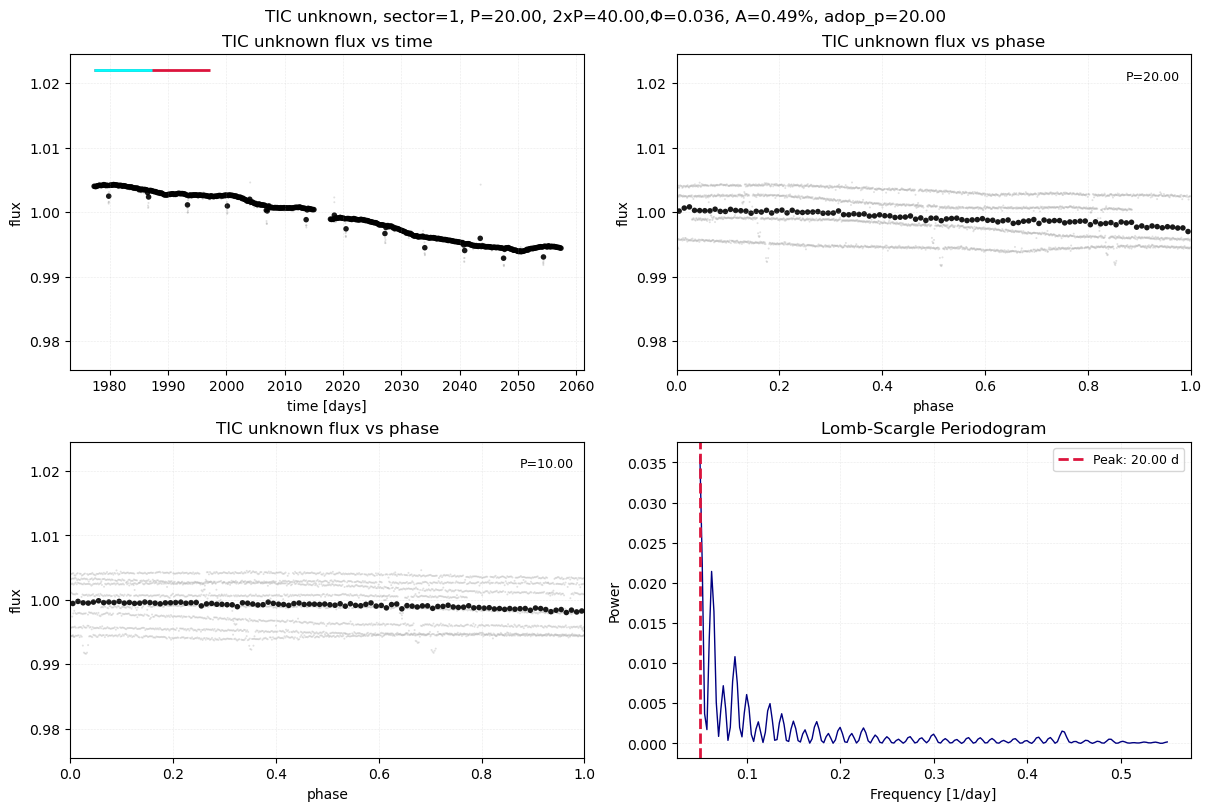

In [4]:
import matplotlib.pyplot as plt
import lightkurve as lk
from pdmpy import pdm

file = '/Users/iansterrett/Downloads/hlsp_k2sff_k2_lightcurve_201546283-c01_kepler_v1_llc.fits'
    
lc = lk.read(file)
ticid = lc.meta.get("TICID", "unknown")
finite = np.isfinite(lc.flux.value)
f = lc.flux.value[finite]

amp = 0.5 * (np.nanpercentile(f, 95) - np.nanpercentile(f, 5))

time, flux = lc.time.value, lc.flux.value

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
ax_time = axes[0, 0]
ax_phase = axes[0, 1]
ax_two_phase = axes[1, 0]
ax_periodogram = axes[1, 1]


def _get_flux_ylim(best_amp_val, flux_vals):
    if np.isfinite(best_amp_val) and best_amp_val > 0:
        return (1 - 5 * best_amp_val, 1 + 5 * best_amp_val)
    finite_flux = flux_vals[np.isfinite(flux_vals)]
    if finite_flux.size:
        f_med = np.nanmedian(finite_flux)
        f_std = np.nanstd(finite_flux)
        if not np.isfinite(f_std) or f_std == 0:
            f_std = 0.1 * abs(f_med) if f_med else 1.0
        return (f_med - 5 * f_std, f_med + 5 * f_std)
    return None

ax_time.scatter(time, flux, s=2, color="0.7", alpha=0.4, edgecolor="none", linewidths=0)
bin_width_days = 4.0 / 24.0
binned_time, binned_flux = _bin_series_fixed_width(time, flux, bin_width_days)
if binned_time.size:
    ax_time.scatter(
        binned_time,
        binned_flux,
        s=16,
        color="k",
        alpha=0.9,
        edgecolor="none",
        linewidths=0,
    )
ax_time.set_xlabel("time [days]")
ax_time.set_ylabel("flux")
ax_time.set_title(f"TIC {ticid} flux vs time")
ax_time.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)
ylims_time = _get_flux_ylim(amp, flux)
ax_time.set_ylim(ylims_time)


frequency, power = LombScargle(time, flux).autopower(minimum_frequency = 1/20, maximum_frequency = 0.55)  # just chose frequency range manually

# extracting the period 
sector = 1

max_power_index = np.argmax(power)

max_frequency = frequency[max_power_index]

period = 1 / max_frequency

print("period in days = ", period)

star_period = period
ylims_phase = _get_flux_ylim(amp, flux)
star_power = np.max(power)
adopted_period = star_period

if np.isfinite(period) and period > 0:
    time0 = np.nanmin(time)
    phase = np.mod(time - time0, period) / period
    ax_phase.scatter(phase, flux, s=2, color="0.7", alpha=0.4, edgecolor="none", linewidths=0)
    phase_edges = np.linspace(0, 1, 101)
    binned_phase, binned_phase_flux = _bin_series_by_edges(phase, flux, phase_edges)
    if binned_phase.size:
        ax_phase.scatter(
            binned_phase,
            binned_phase_flux,
            s=16,
            color="k",
            alpha=0.9,
            edgecolor="none",
            linewidths=0,
        )
    ax_phase.set_xlim(0, 1)
    ax_phase.text(
        0.98,
        0.95,
        f"P={period:.2f}",
        transform=ax_phase.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        color="k",
    )
    if ylims_phase:
        ax_phase.set_ylim(ylims_phase)
    if ylims_time:
        y_line = ylims_time[1] - 0.05 * (ylims_time[1] - ylims_time[0])
    else:
        y_line = ax_time.get_ylim()[1]
    x_start = np.nanmin(time)
    x_end = x_start + period
    ax_time.hlines(y_line, x_start, x_end, colors="crimson", linewidth=2, zorder=5)
else:
    ax_phase.text(
        0.5,
        0.5,
        "No valid first_period",
        ha="center",
        va="center",
        transform=ax_phase.transAxes,
    )
    if ylims_phase:
        ax_phase.set_ylim(ylims_phase)
ax_phase.set_xlabel("phase")
ax_phase.set_ylabel("flux")
ax_phase.set_title(f"TIC {ticid} flux vs phase")
ax_phase.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)

period = 0.5*star_period
ylims_phase = _get_flux_ylim(amp, flux)
if np.isfinite(period) and period > 0:
    time0 = np.nanmin(time)
    phase = np.mod(time - time0, period) / period
    ax_two_phase.scatter(phase, flux, s=2, color="0.7", alpha=0.4, edgecolor="none", linewidths=0)
    phase_edges = np.linspace(0, 1, 101)
    binned_phase, binned_phase_flux = _bin_series_by_edges(phase, flux, phase_edges)
    if binned_phase.size:
        ax_two_phase.scatter(
            binned_phase,
            binned_phase_flux,
            s=16,
            color="k",
            alpha=0.9,
            edgecolor="none",
            linewidths=0,
        )
    ax_two_phase.set_xlim(0, 1)
    ax_two_phase.text(
        0.98,
        0.95,
        f"P={period:.2f}",
        transform=ax_two_phase.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        color="k",
    )
    if ylims_phase:
        ax_two_phase.set_ylim(ylims_phase)
    if ylims_time:
        y_line = ylims_time[1] - 0.05 * (ylims_time[1] - ylims_time[0])
    else:
        y_line = ax_time.get_ylim()[1]

    x_start = np.nanmin(time)
    x_end = x_start + period
    ax_time.hlines(y_line, x_start, x_end, colors="cyan", linewidth=2, zorder=10)
    #ax_time.hlines(y_line, x_start, x_end, colors="", linewidth=2)
else:
    ax_two_phase.text(
        0.5,
        0.5,
        "No valid first_period",
        ha="center",
        va="center",
        transform=ax_two_phase.transAxes,
    )
    if ylims_phase:
        ax_two_phase.set_ylim(ylims_phase)
ax_two_phase.set_xlabel("phase")
ax_two_phase.set_ylabel("flux")
ax_two_phase.set_title(f"TIC {ticid} flux vs phase")
ax_two_phase.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)


    ####
    
# ax_zoom.scatter(time, flux, s=2, color="0.7", alpha=1, edgecolor="none")
# bin_width_days = 4.0 / 24.0
# binned_time, binned_flux = _bin_series_fixed_width(time, flux, bin_width_days)
# if binned_time.size:
#     ax_zoom.scatter(
#         binned_time,
#         binned_flux,
#         s=16,
#         color="k",
#         alpha=0.9,
#         edgecolor="none",
#         linewidths=0,
#     )
# ax_zoom.set_xlabel("time [days]")
# ax_zoom.set_ylabel("flux")
# ax_zoom.set_title(f"TIC {ticid} flux vs time")
# ax_zoom.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)
# ylims_time = _get_flux_ylim(amp, flux)
# ax_zoom.set_ylim(ylims_time)
# ax_zoom.set_xlim(time[0], time[0] + 1)

# x_end = np.nanmax(time[0] + 1)
# x_start = x_end - 2*star_period
# ax_zoom.hlines(y_line, x_start, x_end, colors="cyan", linewidth=2)

# x_start = np.nanmax(time[0])
# x_end = x_start + star_period
# ax_zoom.hlines(y_line, x_start, x_end, colors="crimson", linewidth=2)

ax_periodogram.plot(frequency, power, color='navy', linewidth=1)
ax_periodogram.axvline(max_frequency, color='crimson', linestyle='--', linewidth=2, label=f'Peak: {adopted_period:.2f} d')
ax_periodogram.set_xlabel("Frequency [1/day]")
ax_periodogram.set_ylabel("Power")
ax_periodogram.set_title("Lomb-Scargle Periodogram")
ax_periodogram.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)
ax_periodogram.legend(loc='best', fontsize=9)


fig.suptitle(
    f"TIC {ticid}, sector={sector}, P={star_period:.2f}, 2xP={2*star_period:.2f},Φ={star_power:.3f}, A={amp * 100:.2f}%, adop_p={adopted_period:.2f}",
    fontsize=12,
)

plt.savefig(figure, dpi=300, bbox_inches='tight')

plt.close()

  0%|          | 0/162 [00:00<?, ?it/s]

  2%|▏         | 3/162 [00:00<00:11, 13.39it/s]

period in days =  40.0
period in days =  9.264386627761791
period in days =  40.0
period in days =  31.316082087952584


  4%|▍         | 7/162 [00:00<00:13, 11.21it/s]

period in days =  40.0
period in days =  7.999038822169806
period in days =  40.0
period in days =  40.0


...

 98%|█████████▊| 159/162 [00:11<00:00, 15.86it/s]

period in days =  28.530681117149424
period in days =  40.0
period in days =  40.0
period in days =  26.62231760594434


100%|██████████| 162/162 [00:11<00:00, 14.11it/s]


period in days =  40.0
period in days =  12.430064414413737
Error in callback <function _draw_all_if_interactive at 0x15a1911c0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

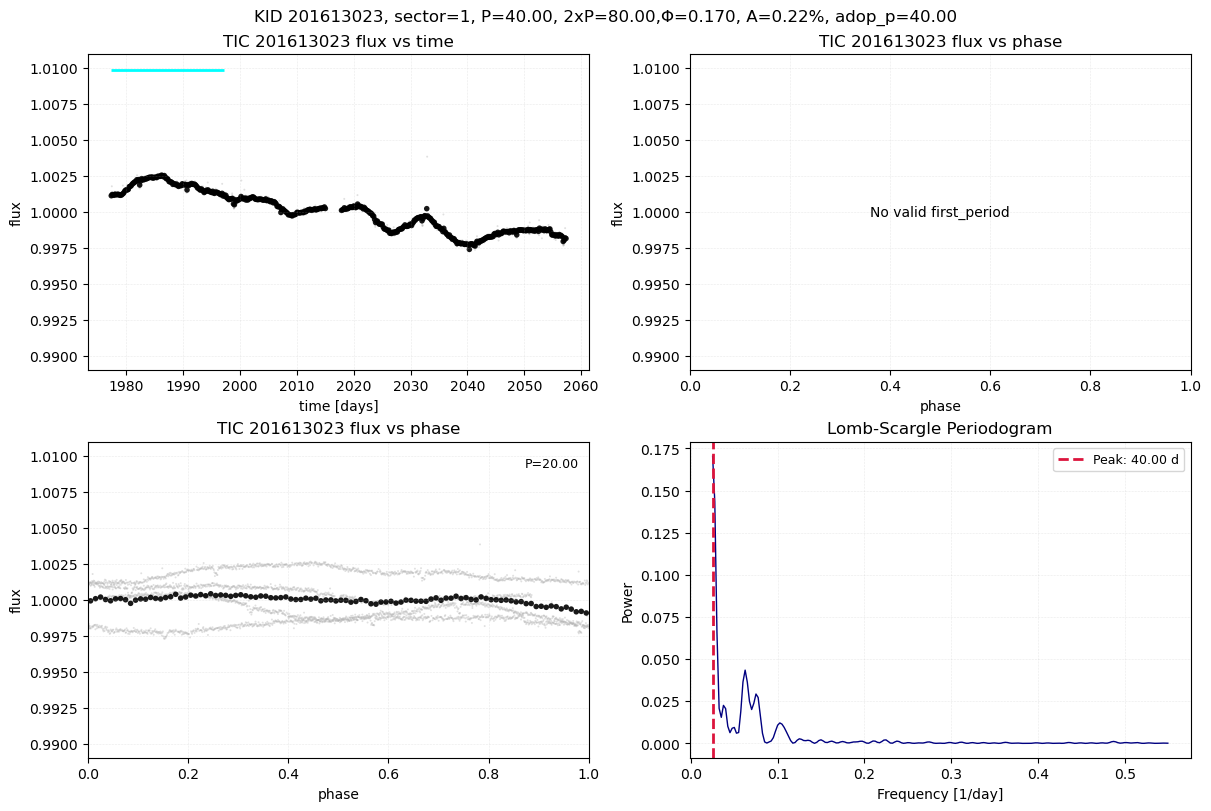

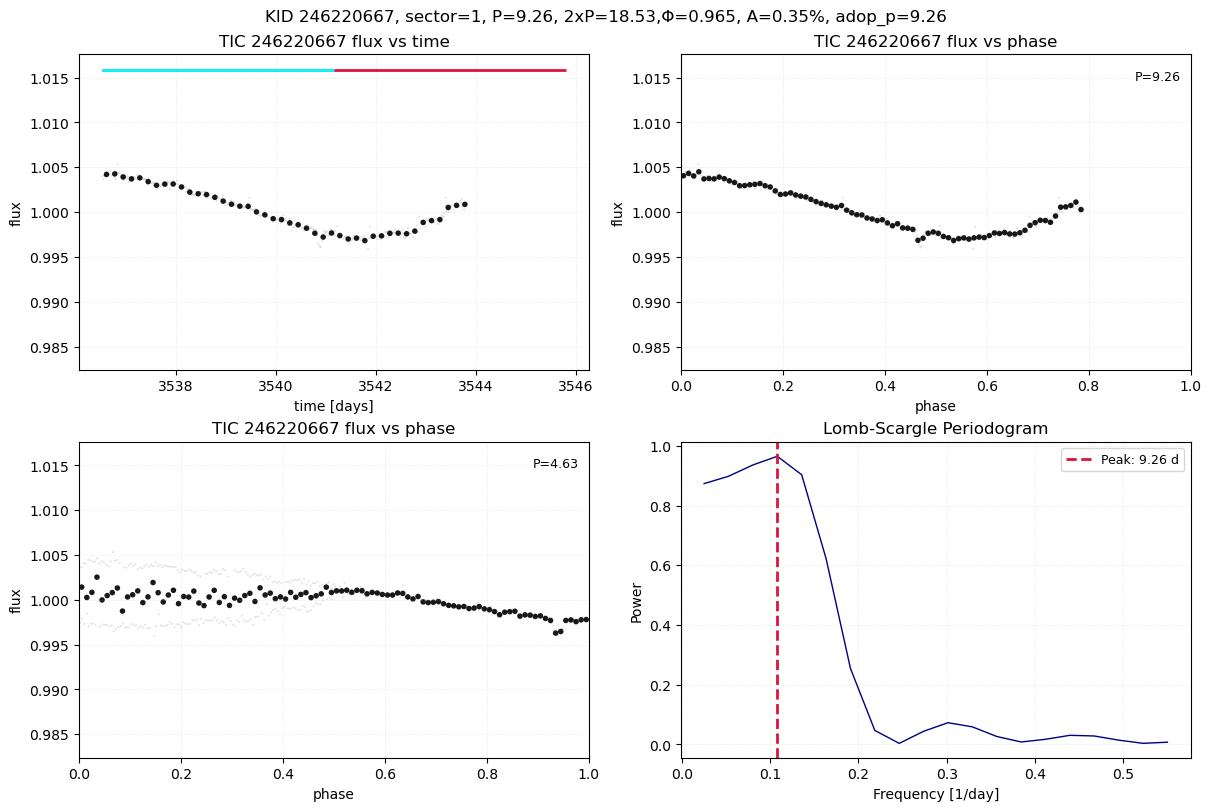

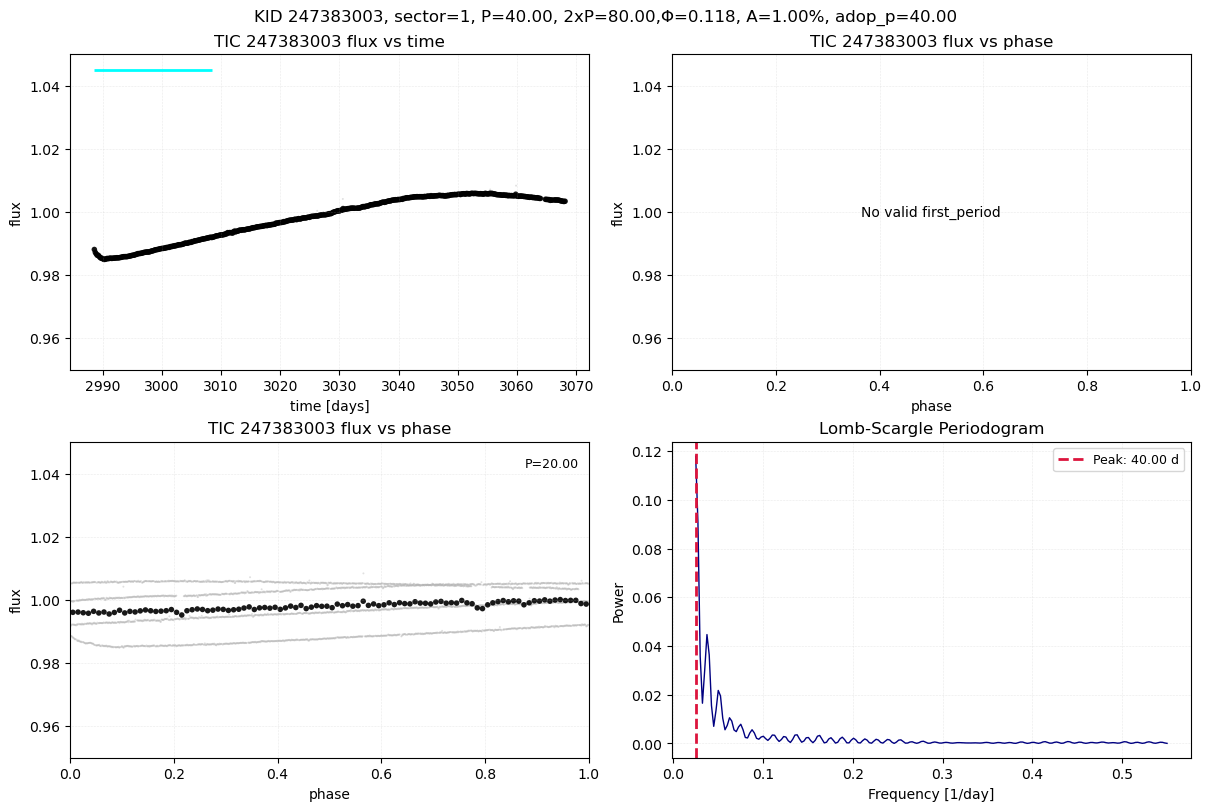

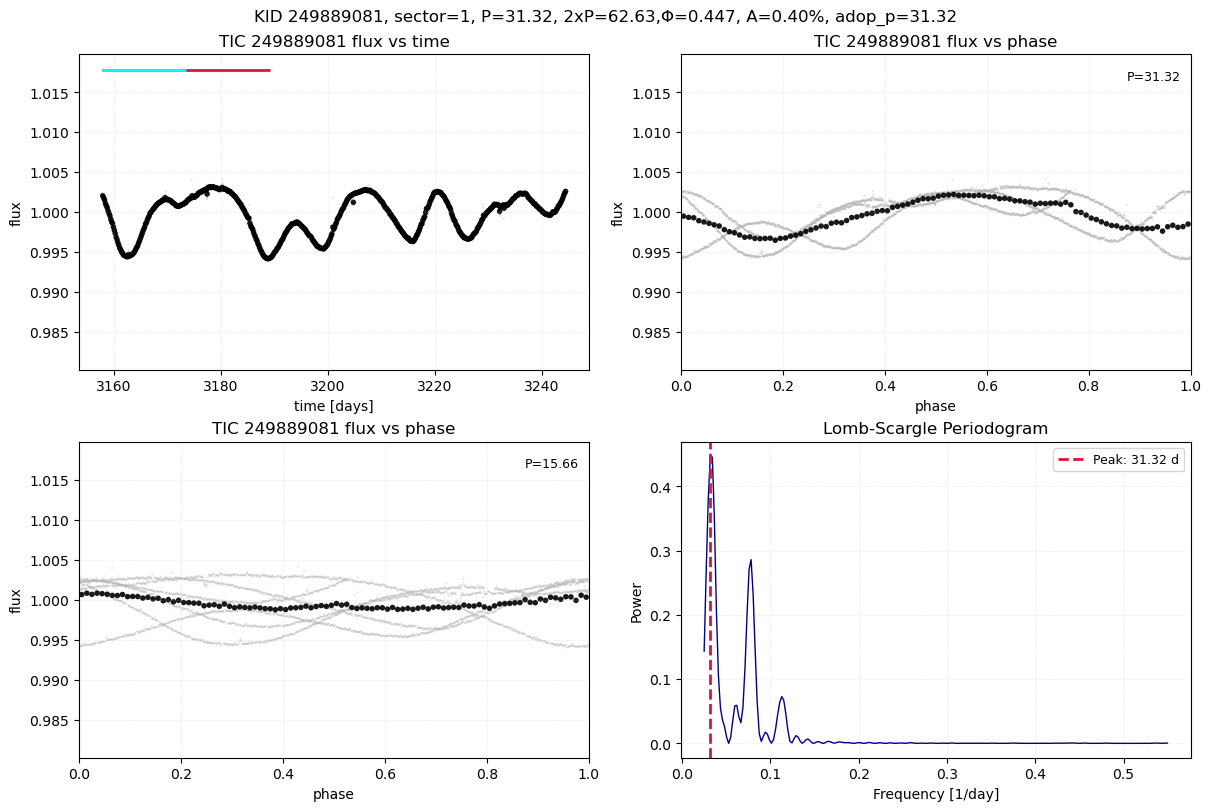

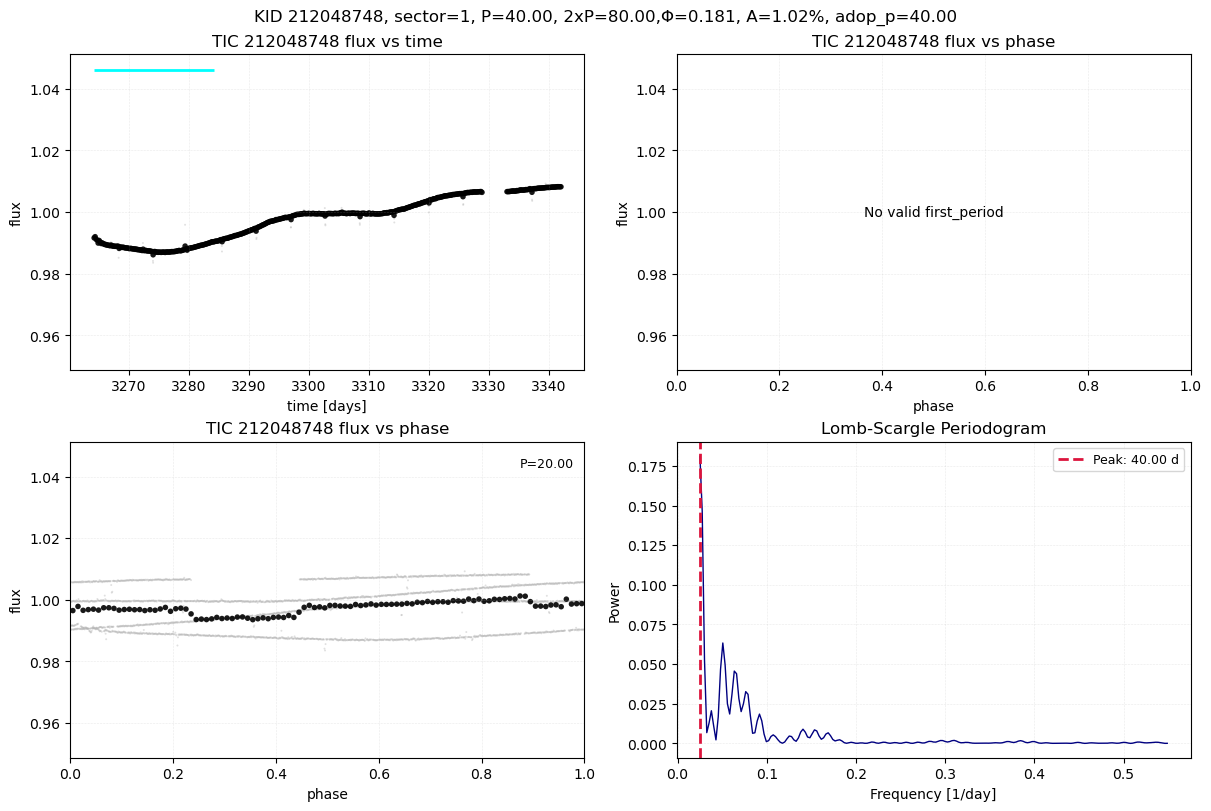

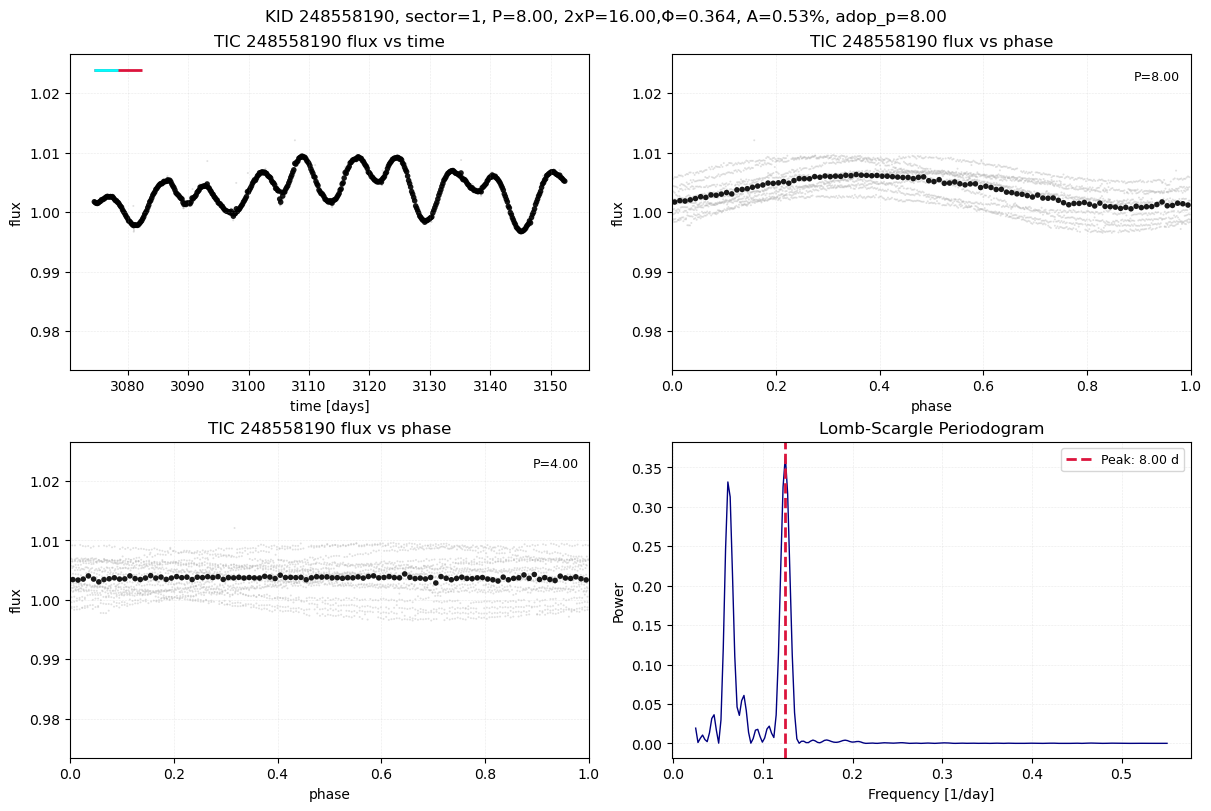

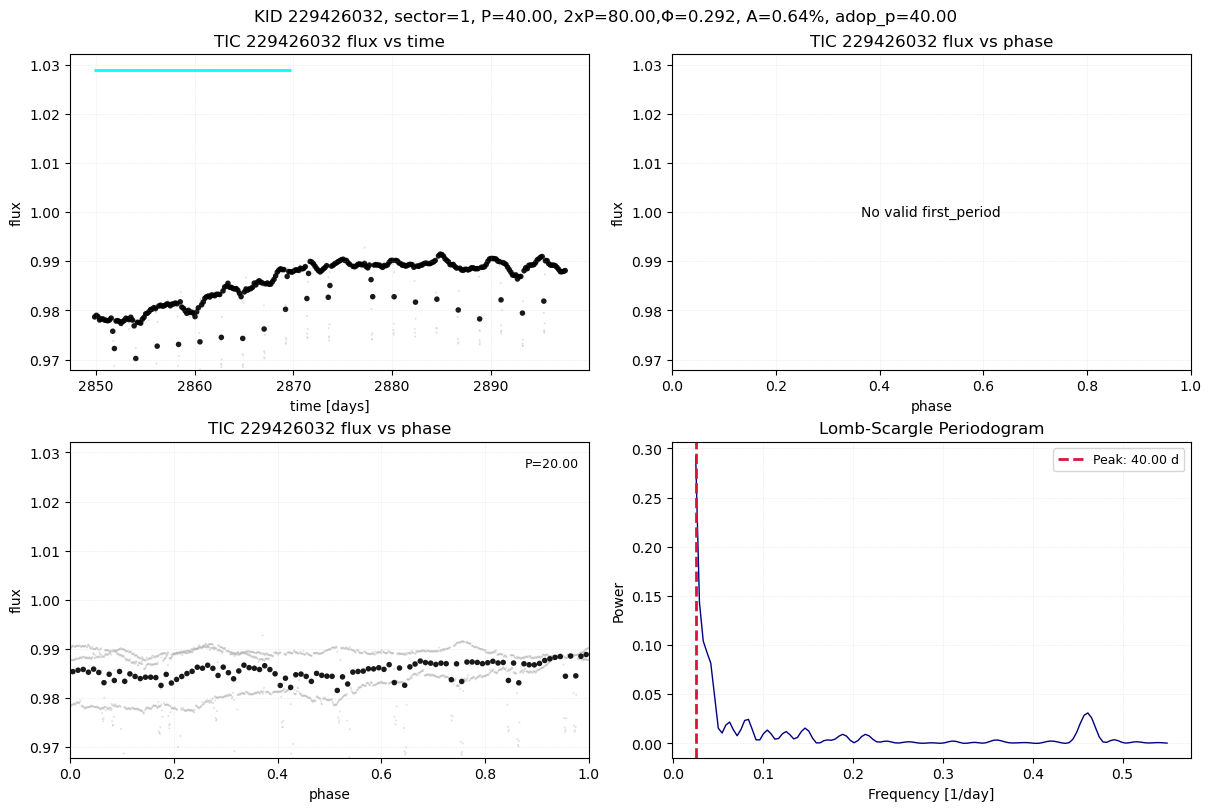

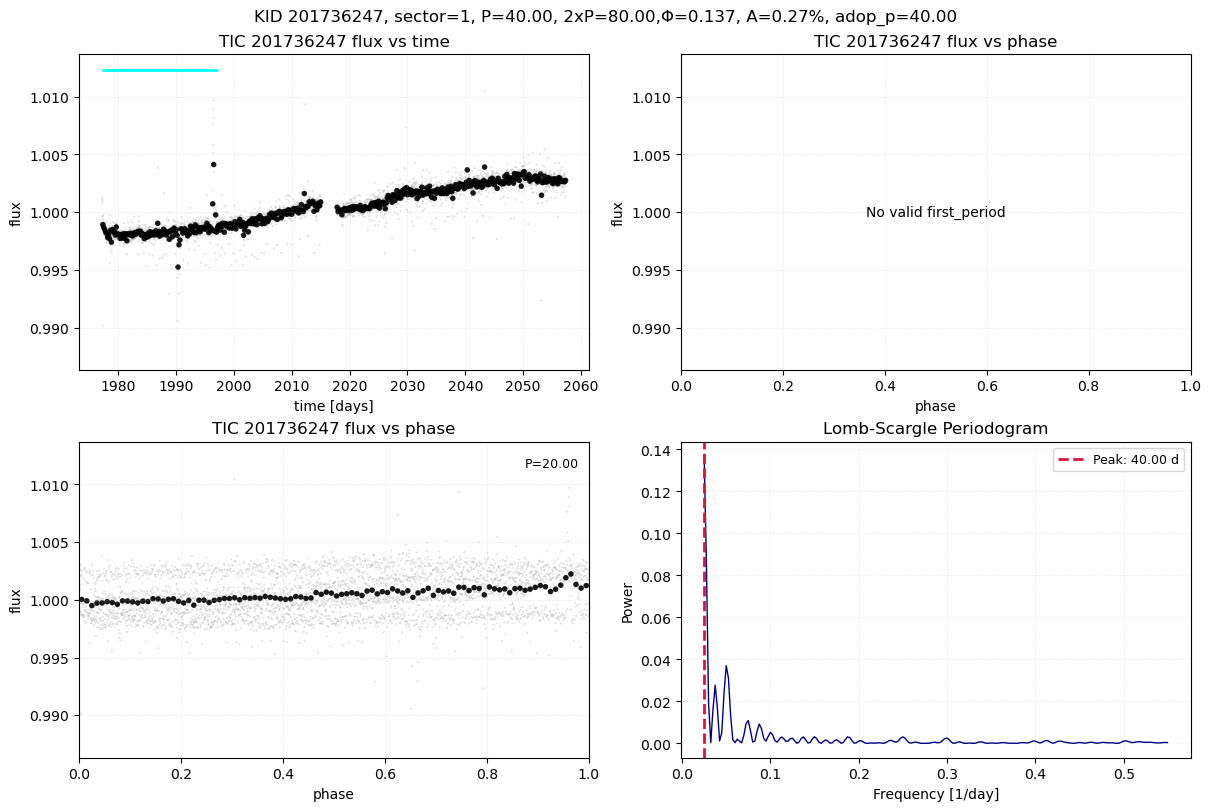

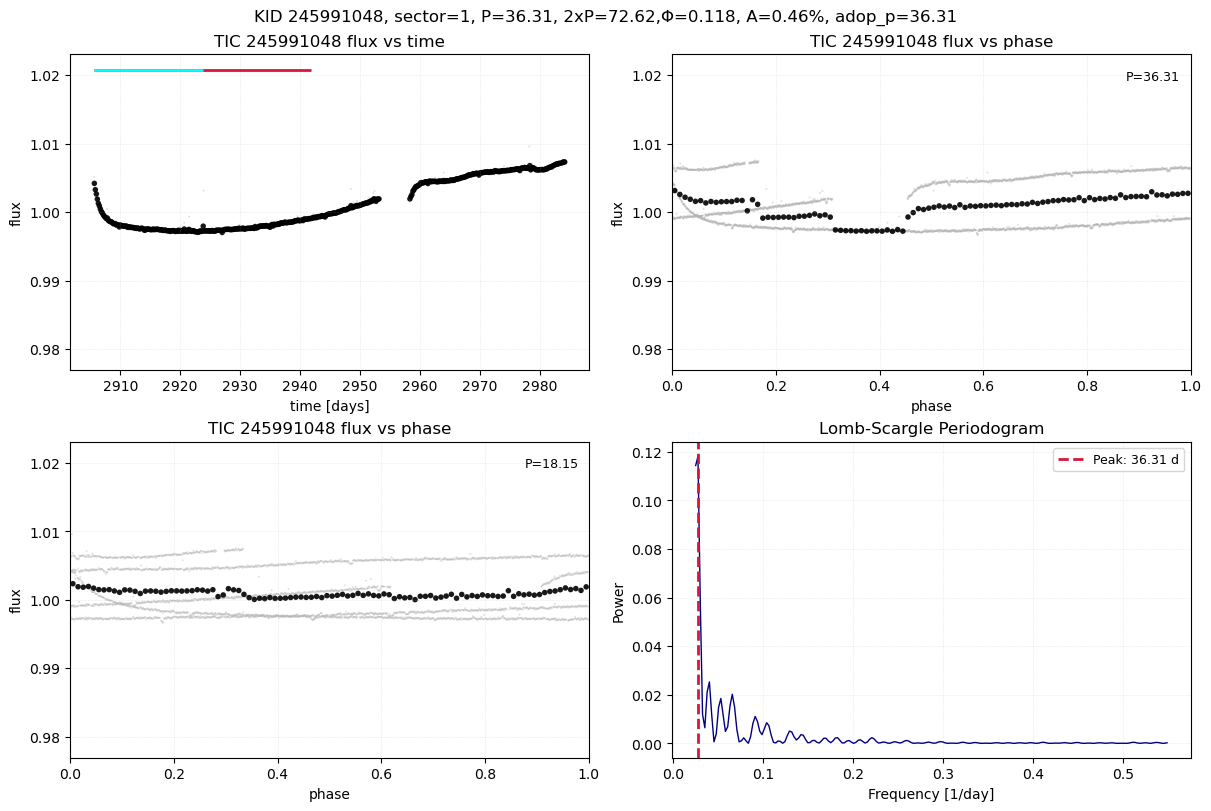

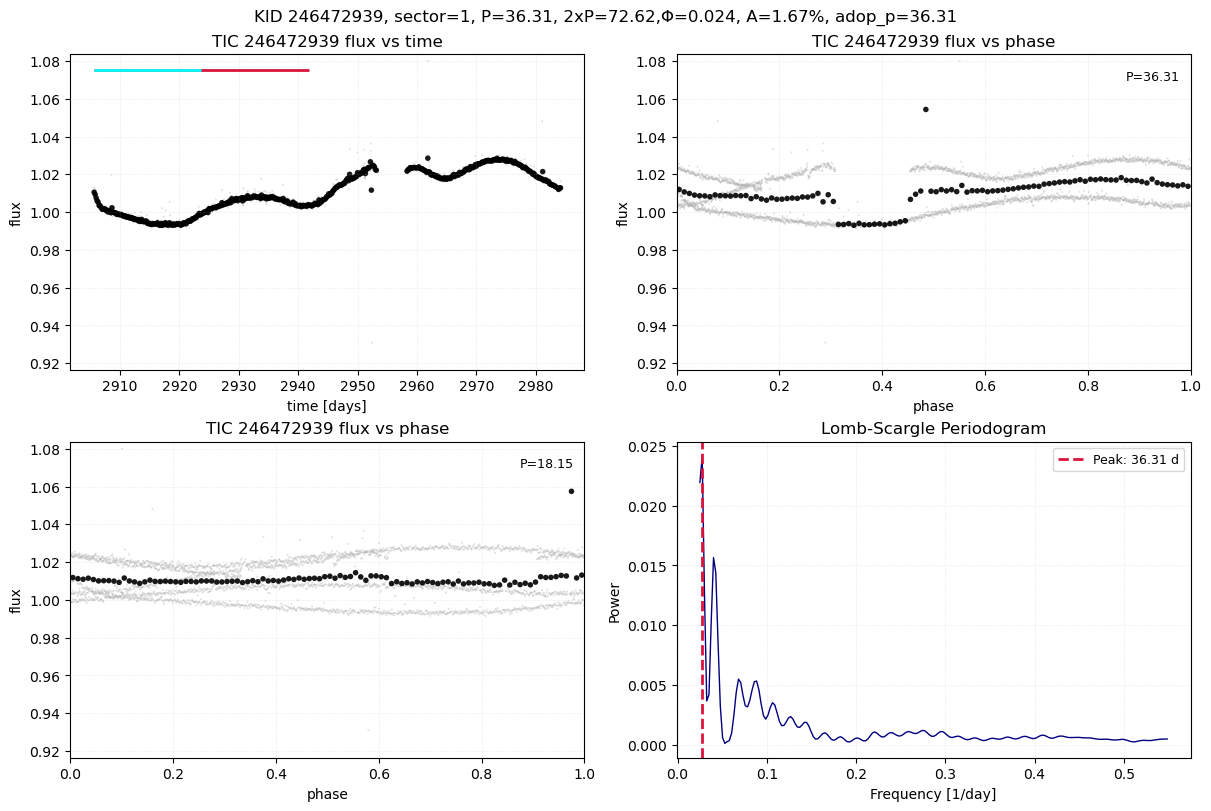

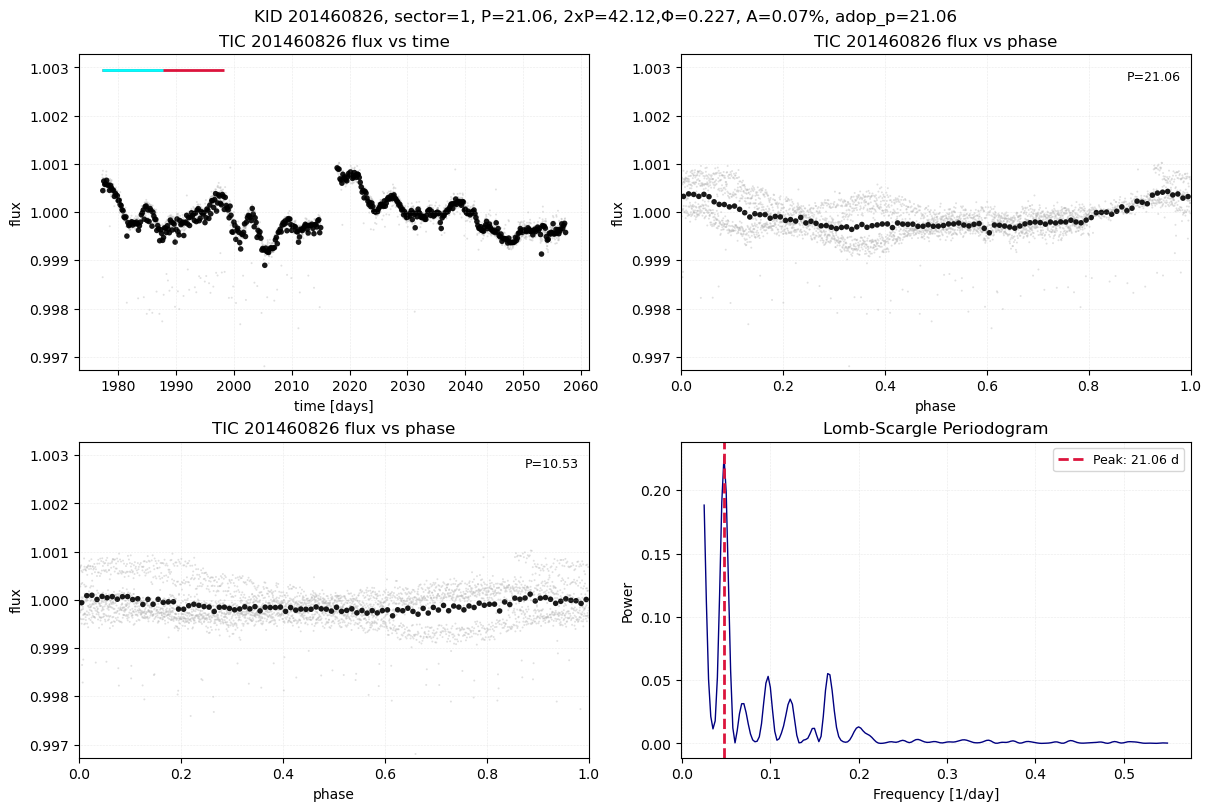

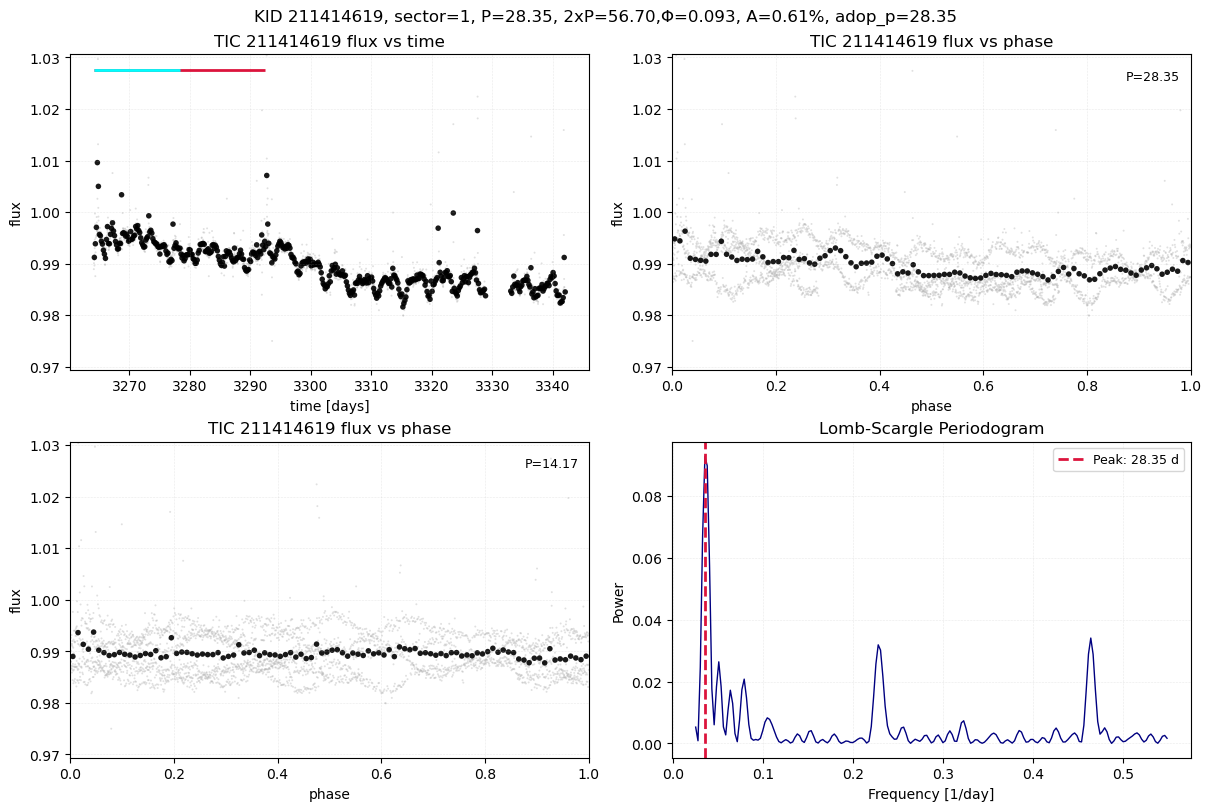

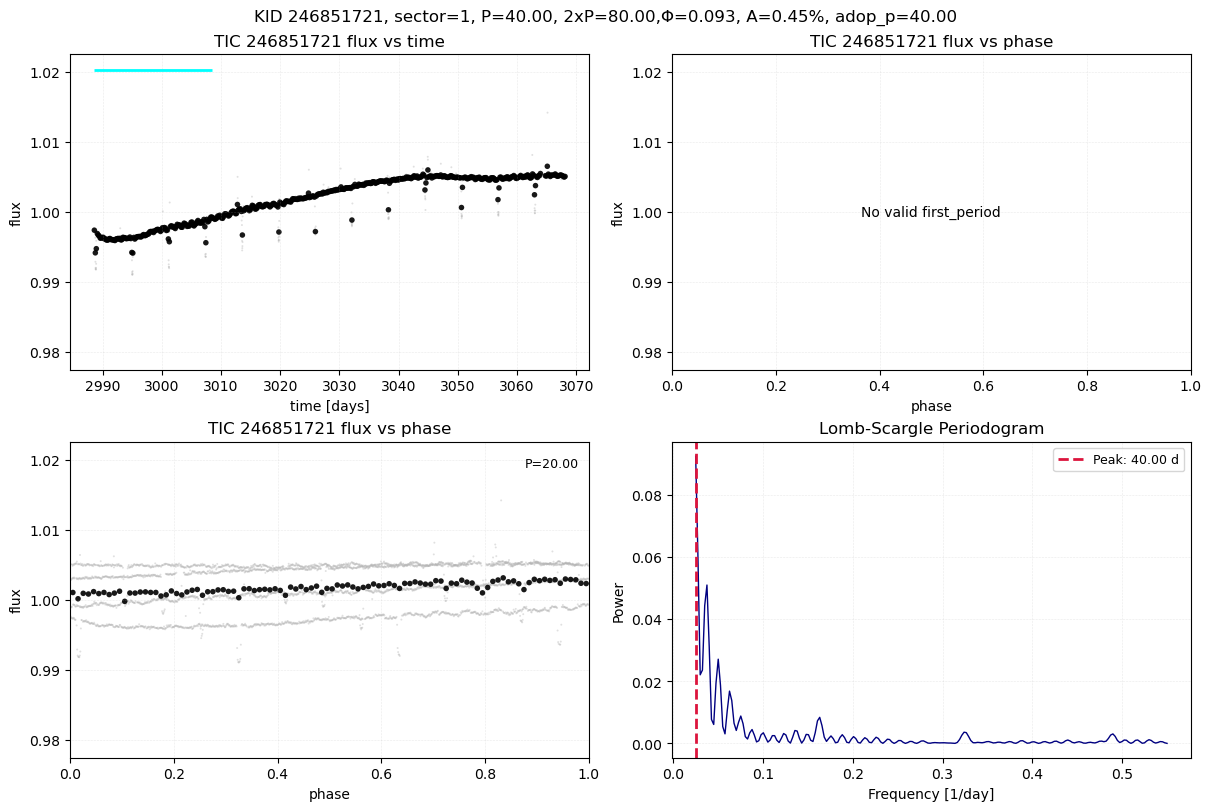

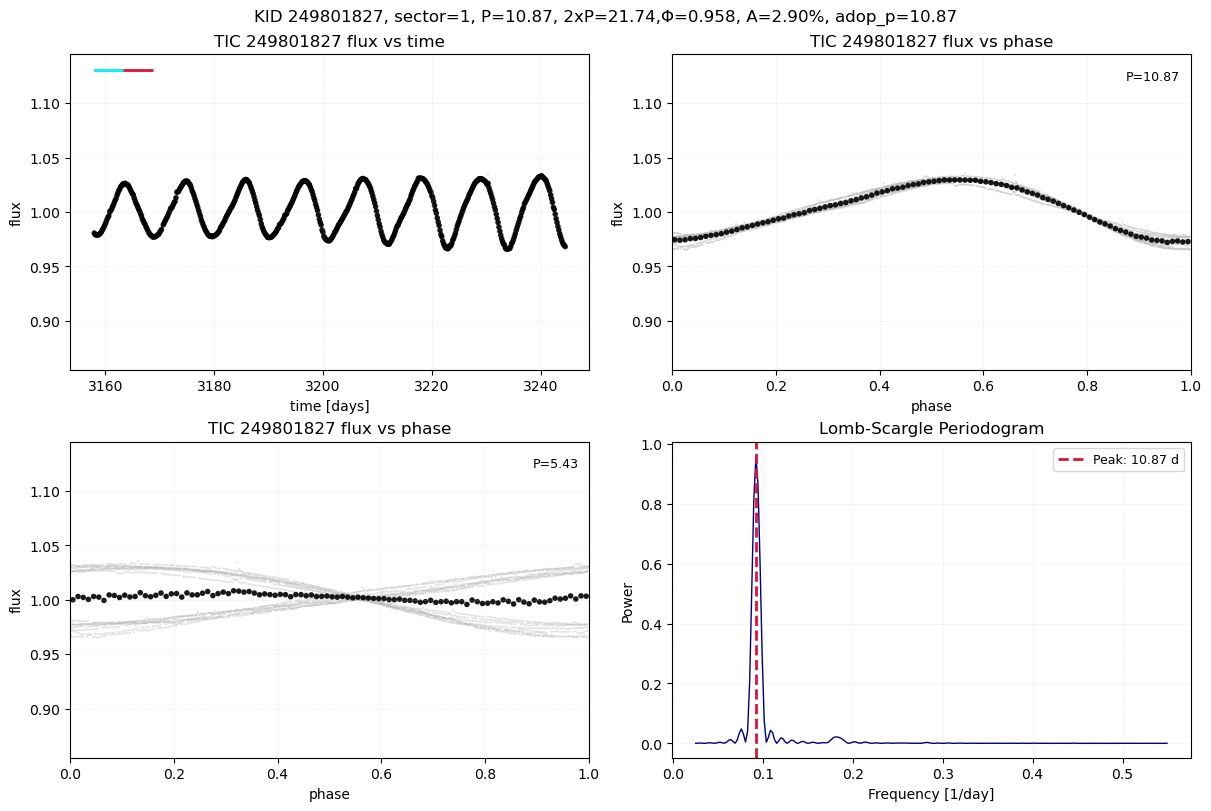

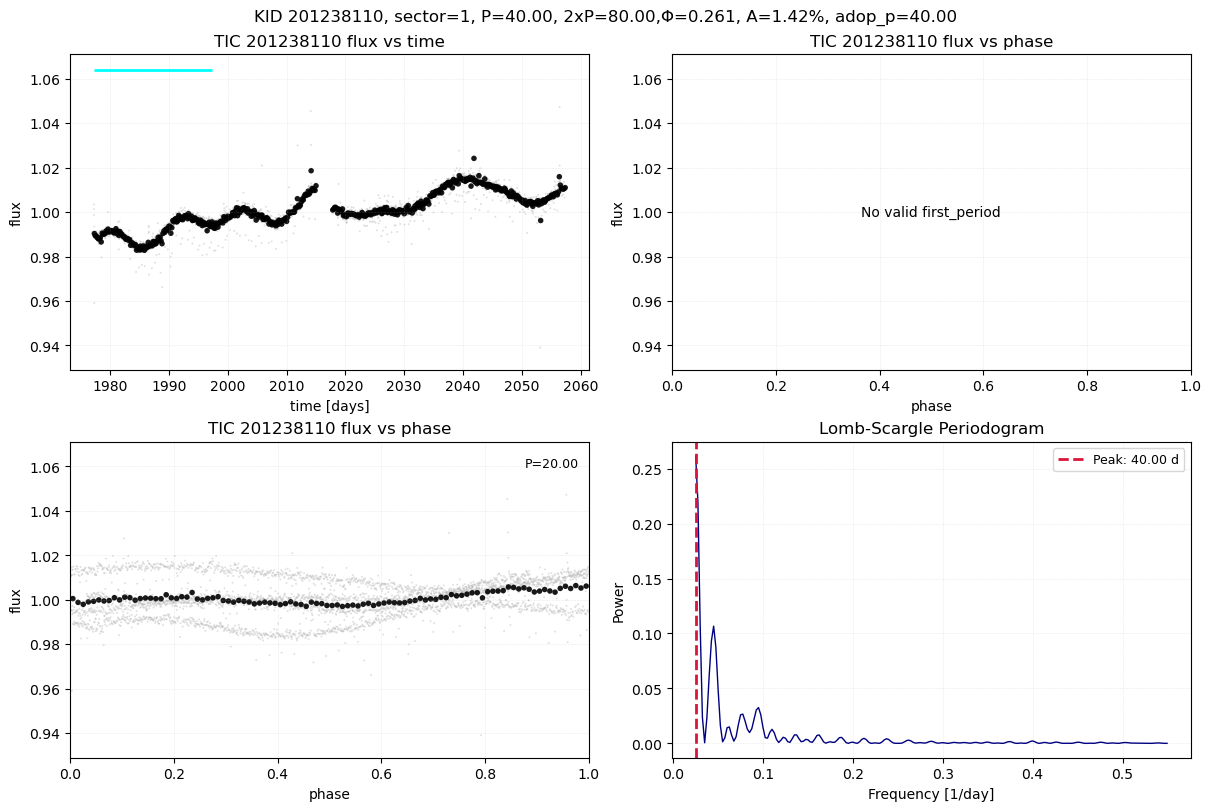

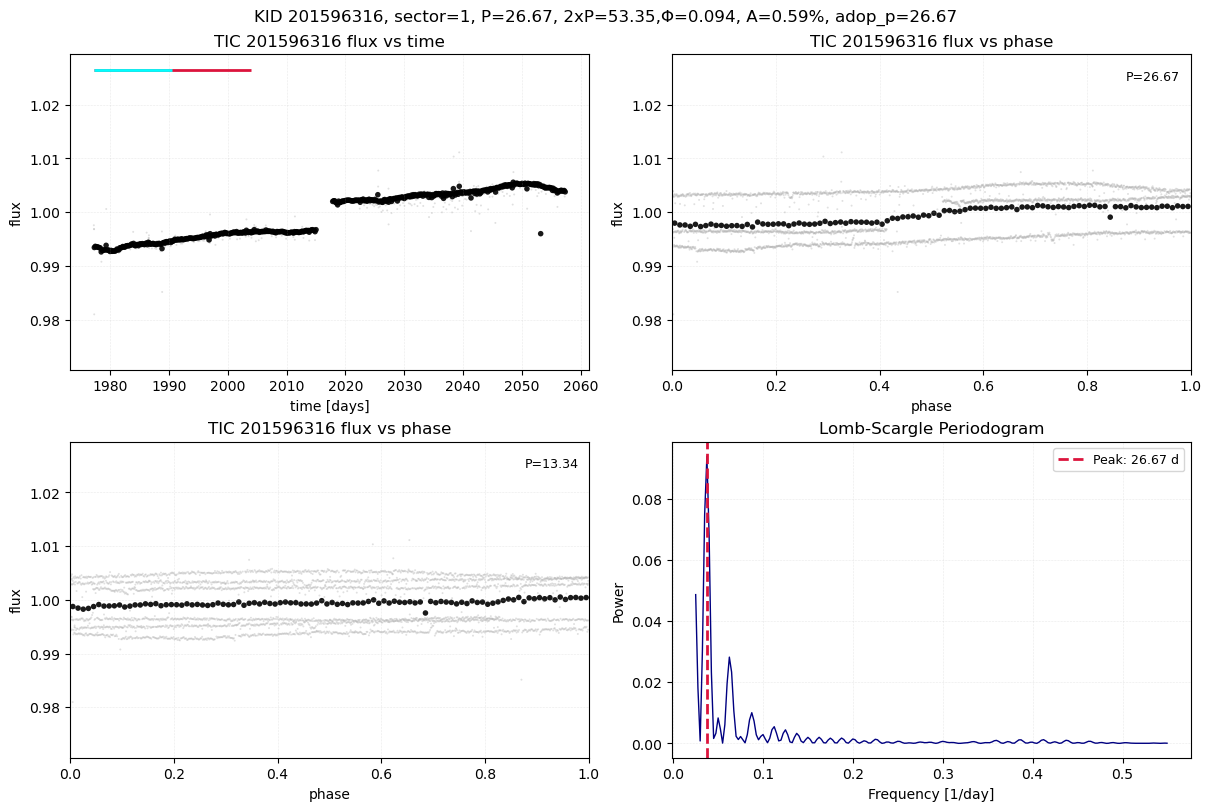

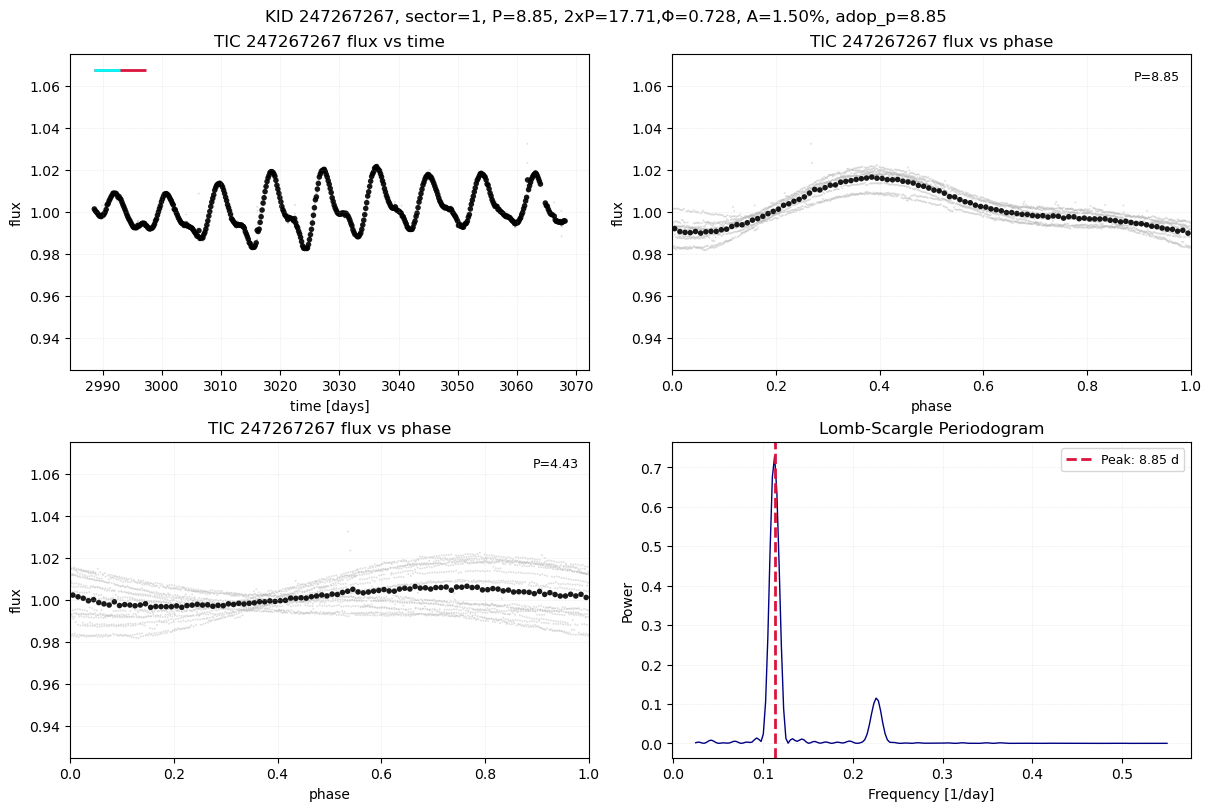

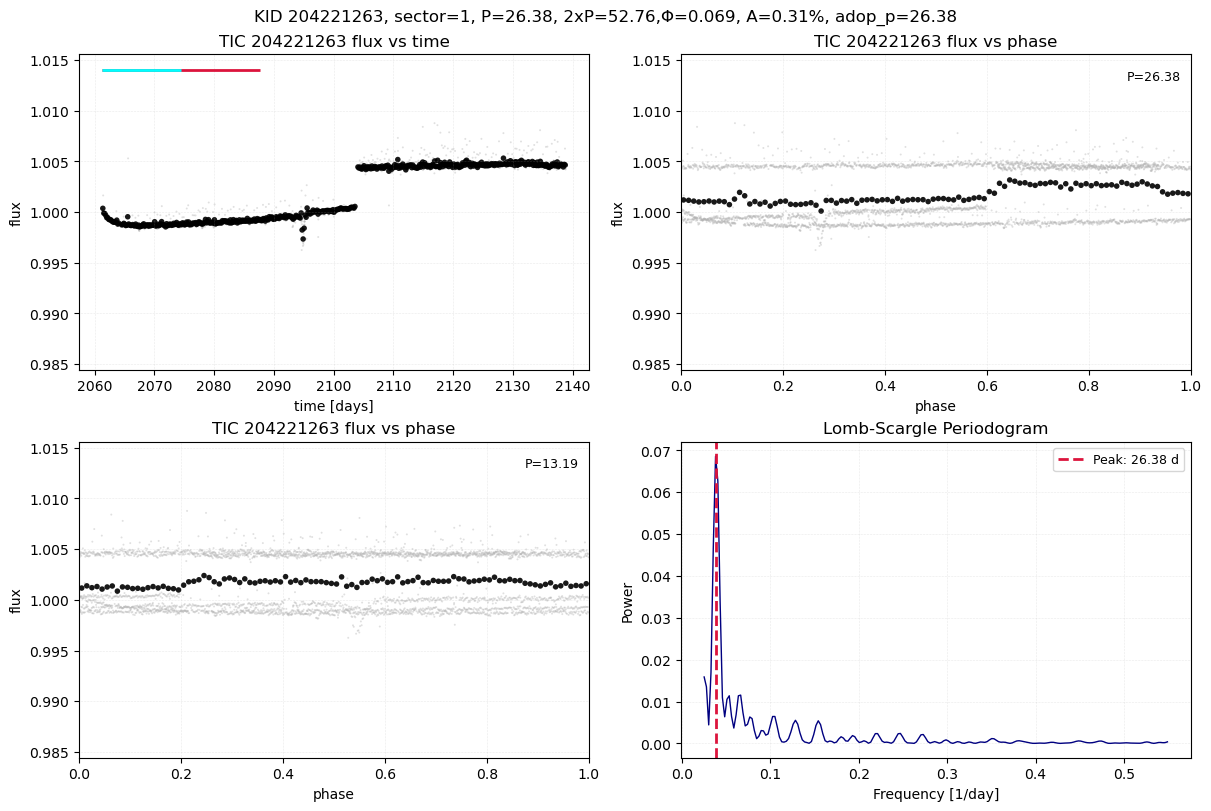

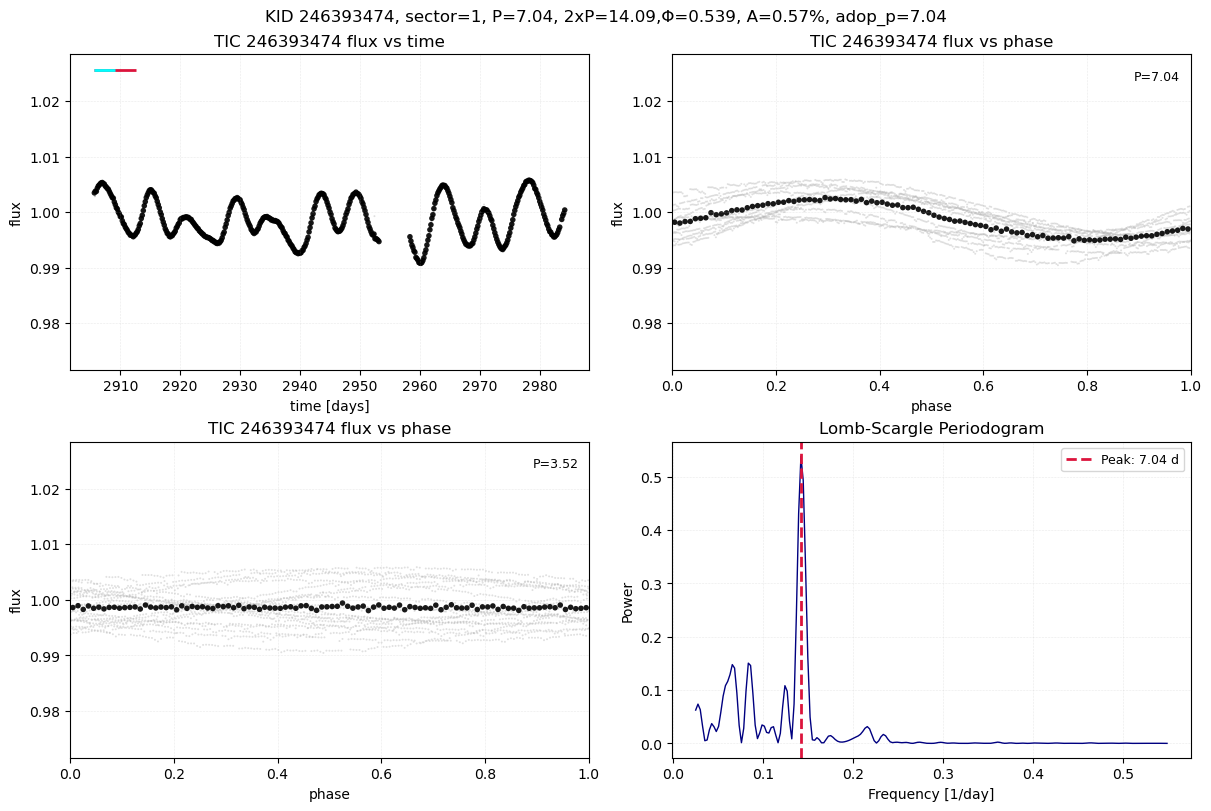

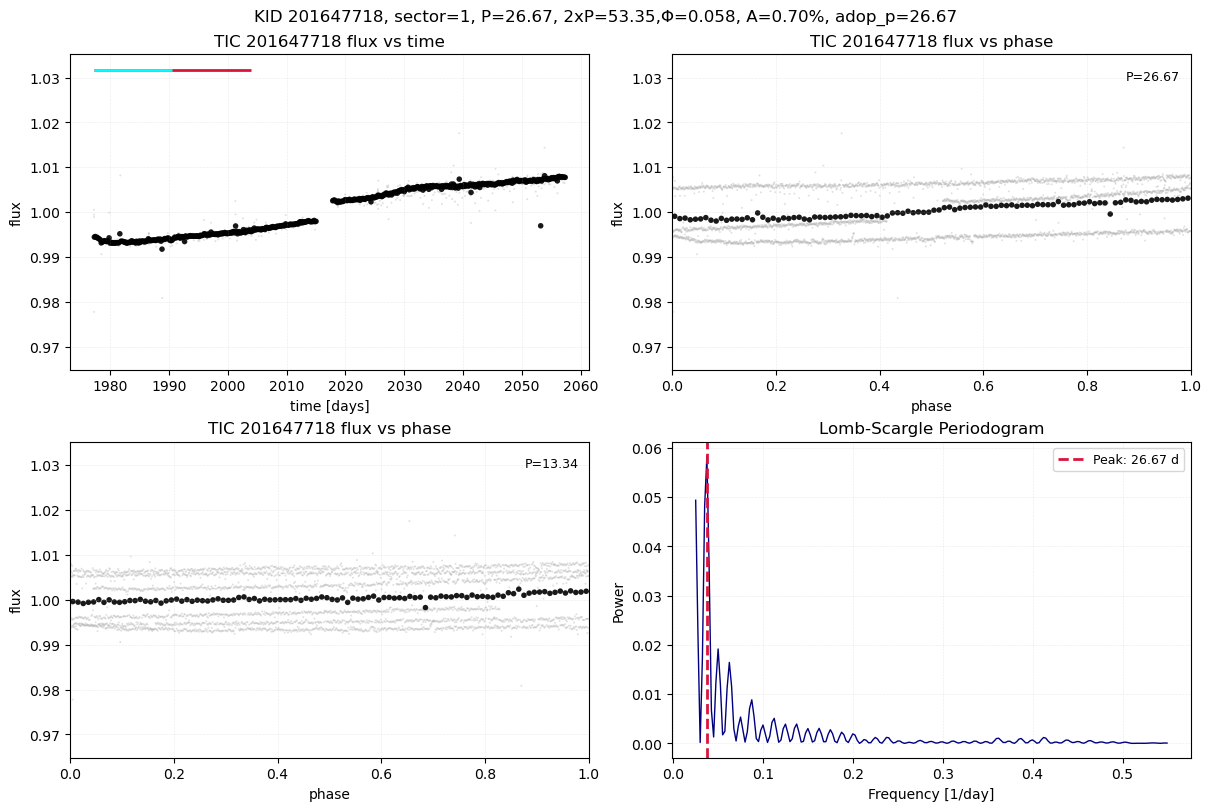

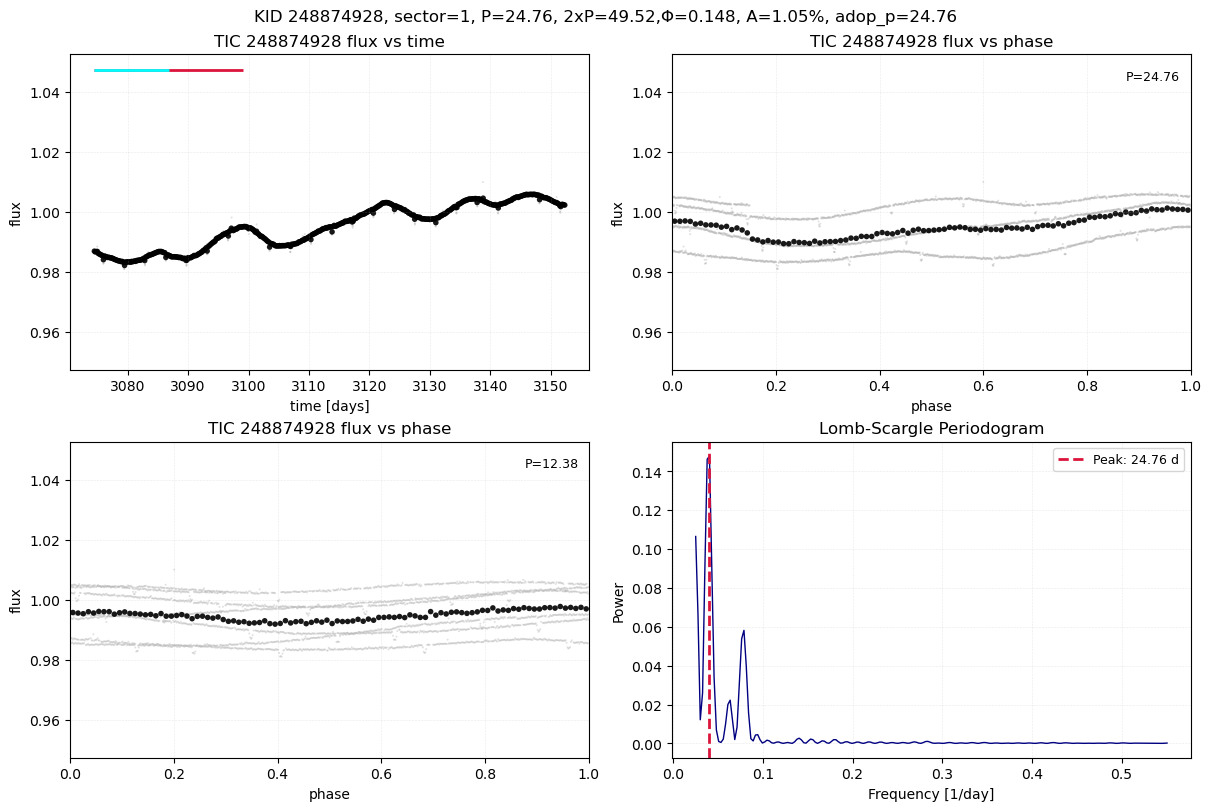

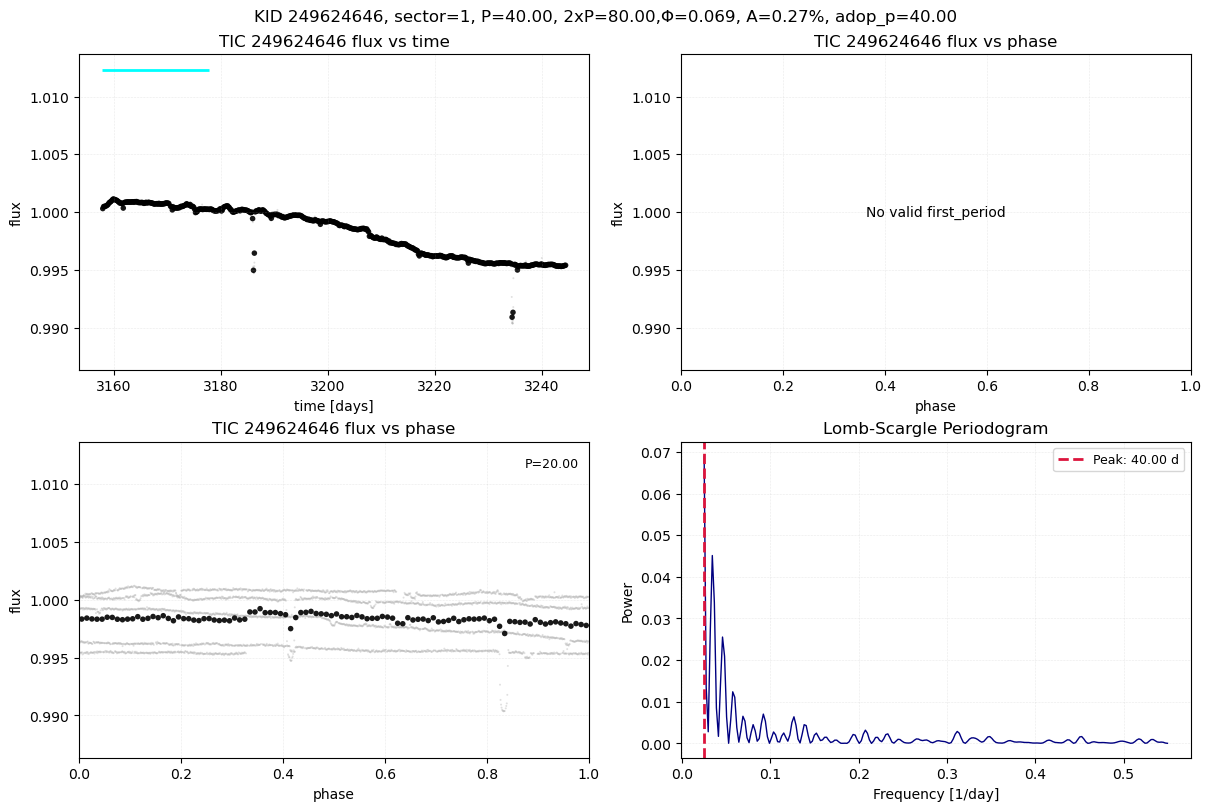

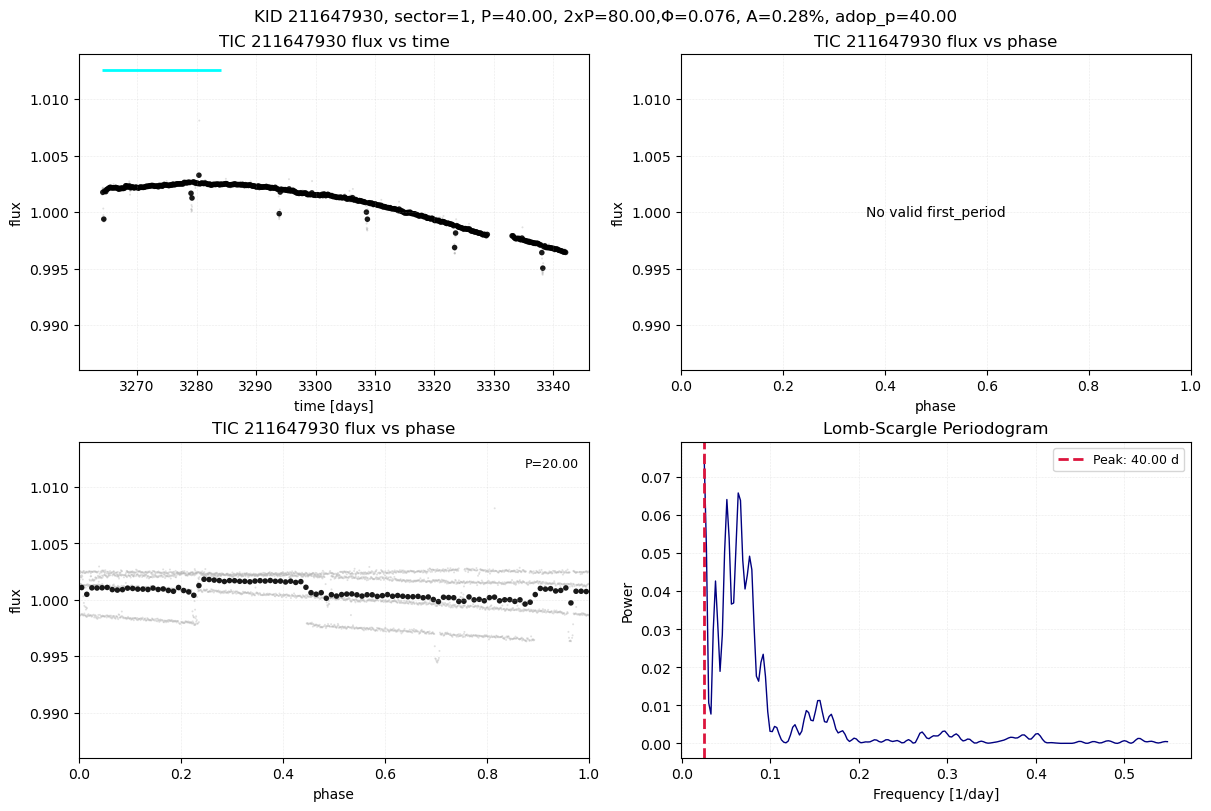

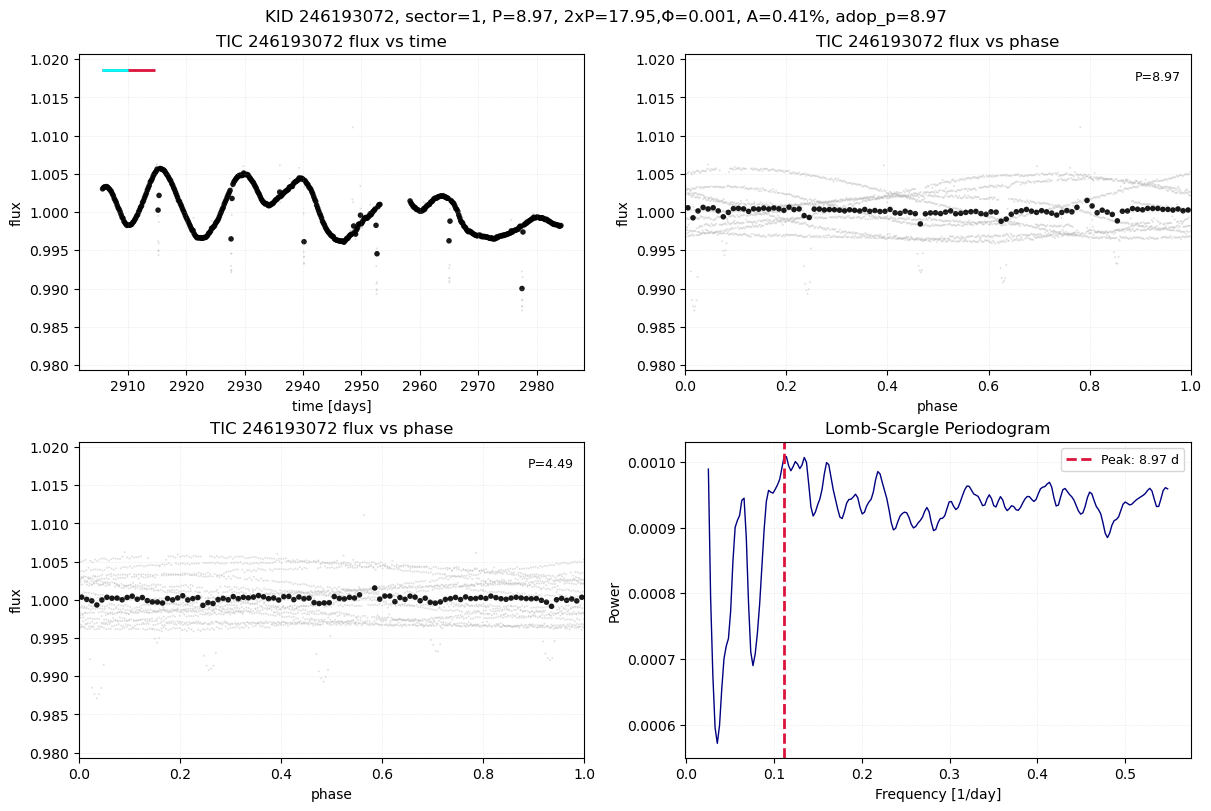

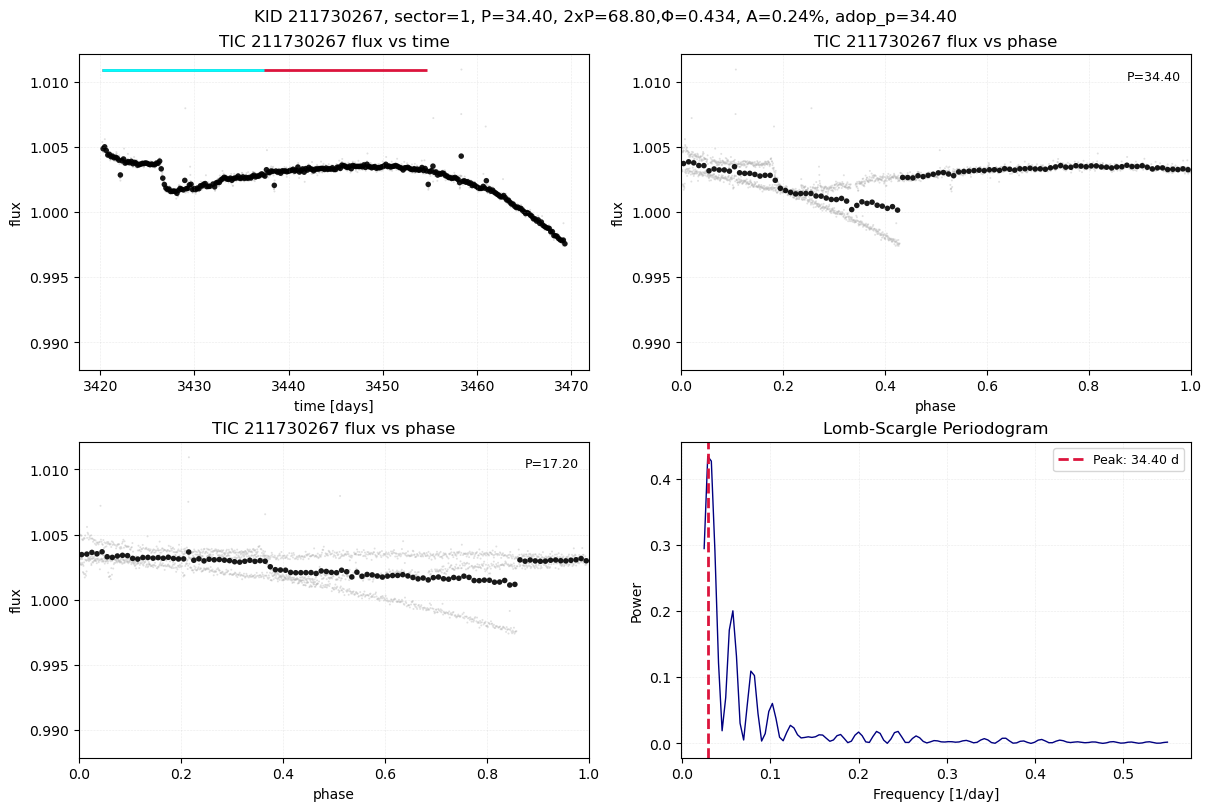

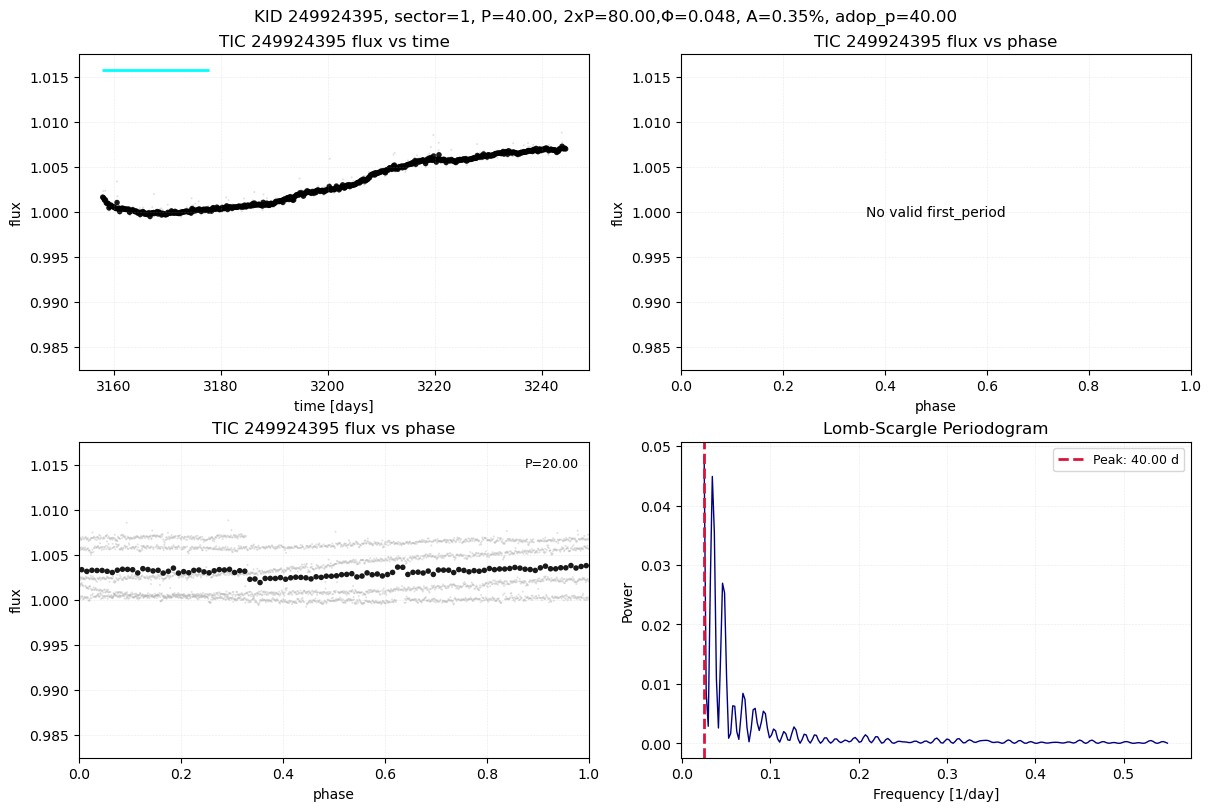

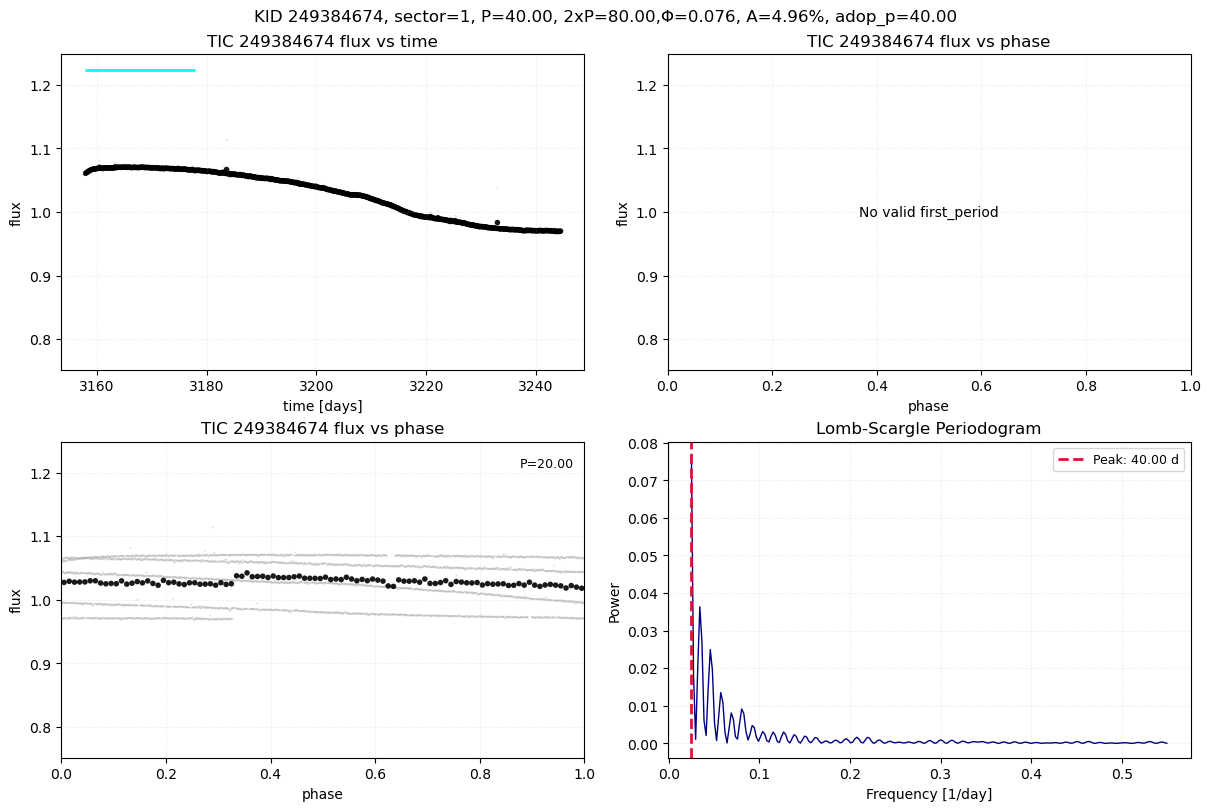

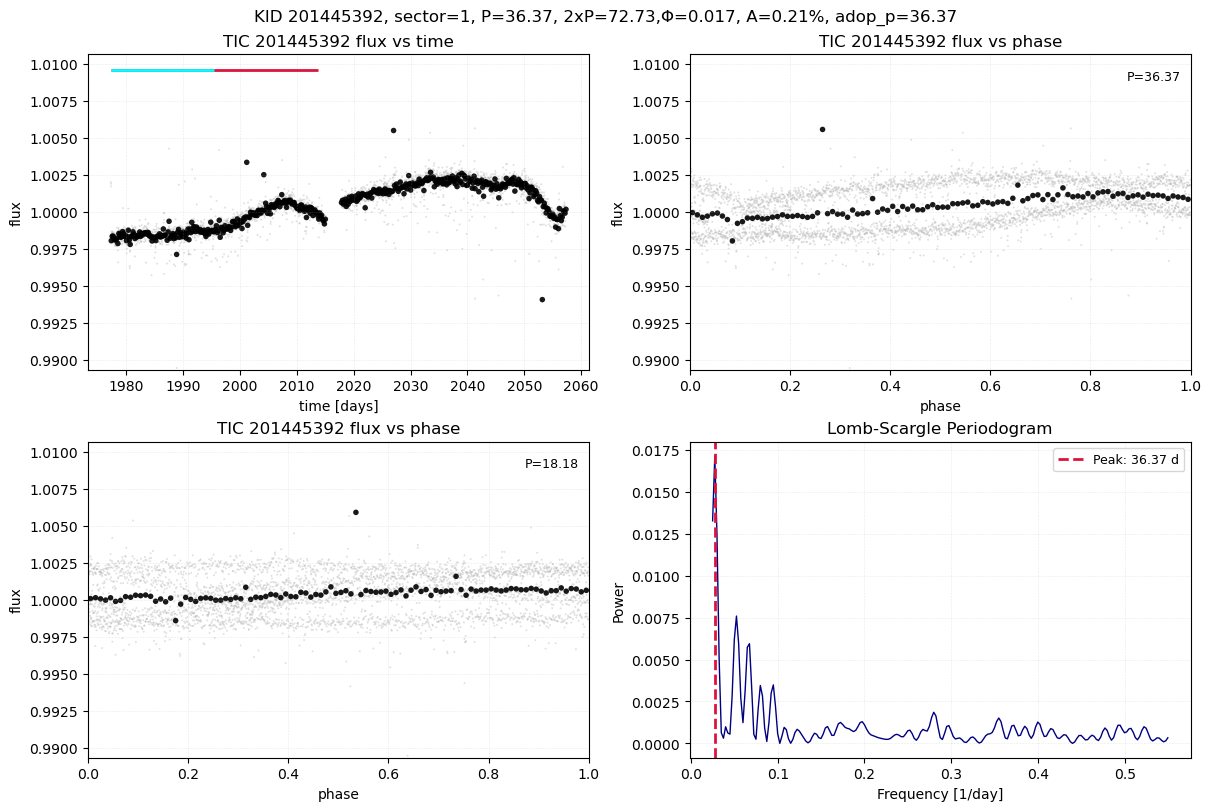

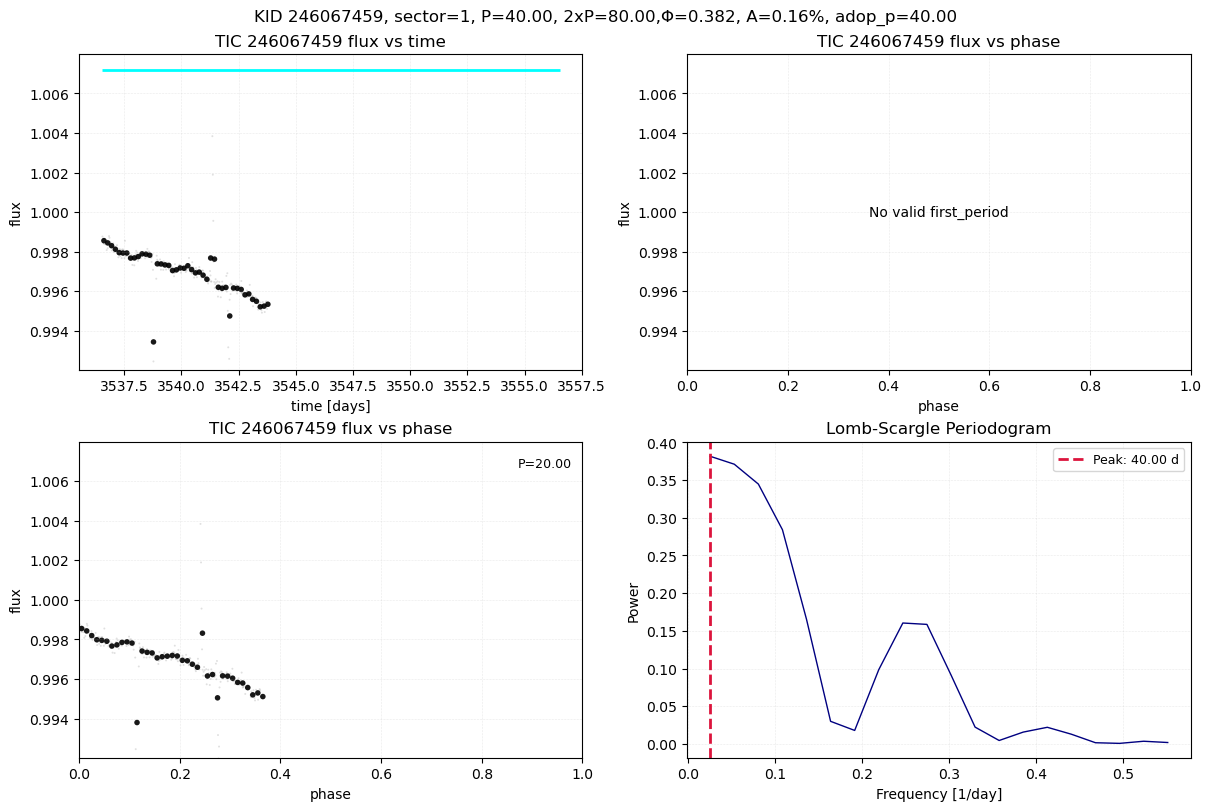

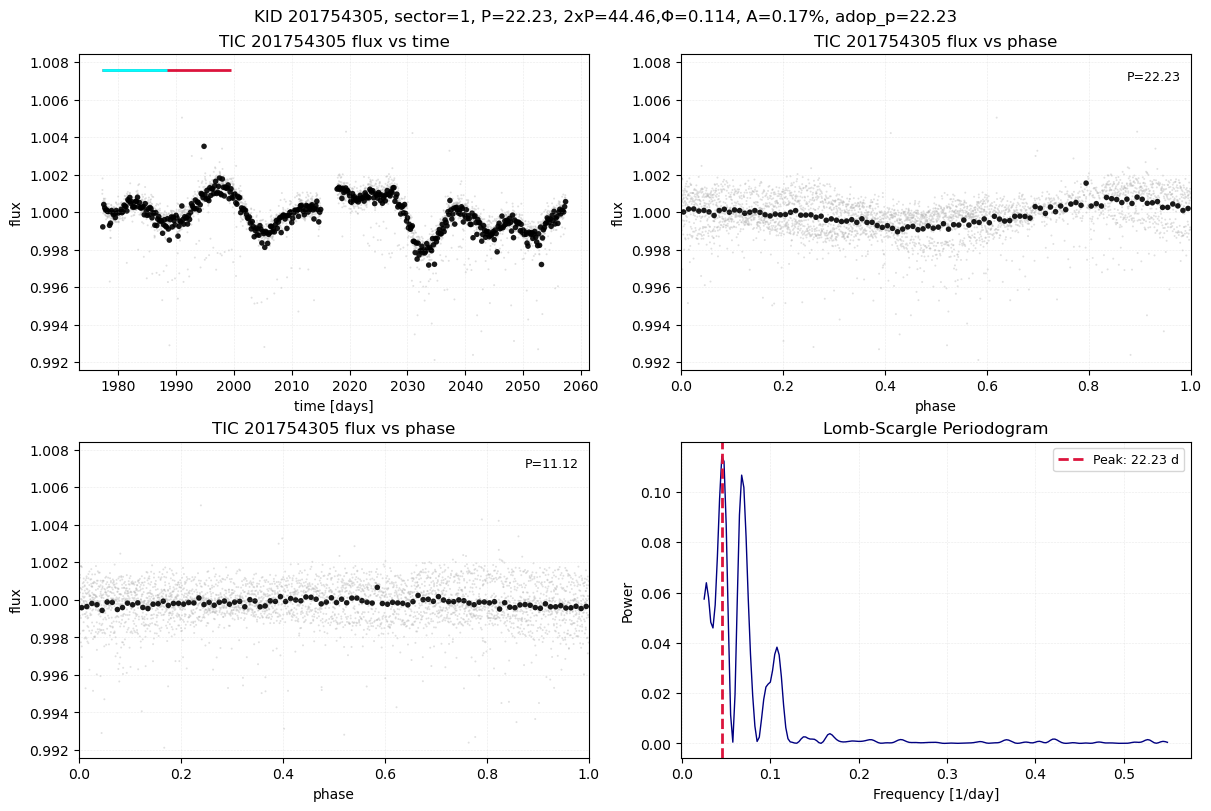

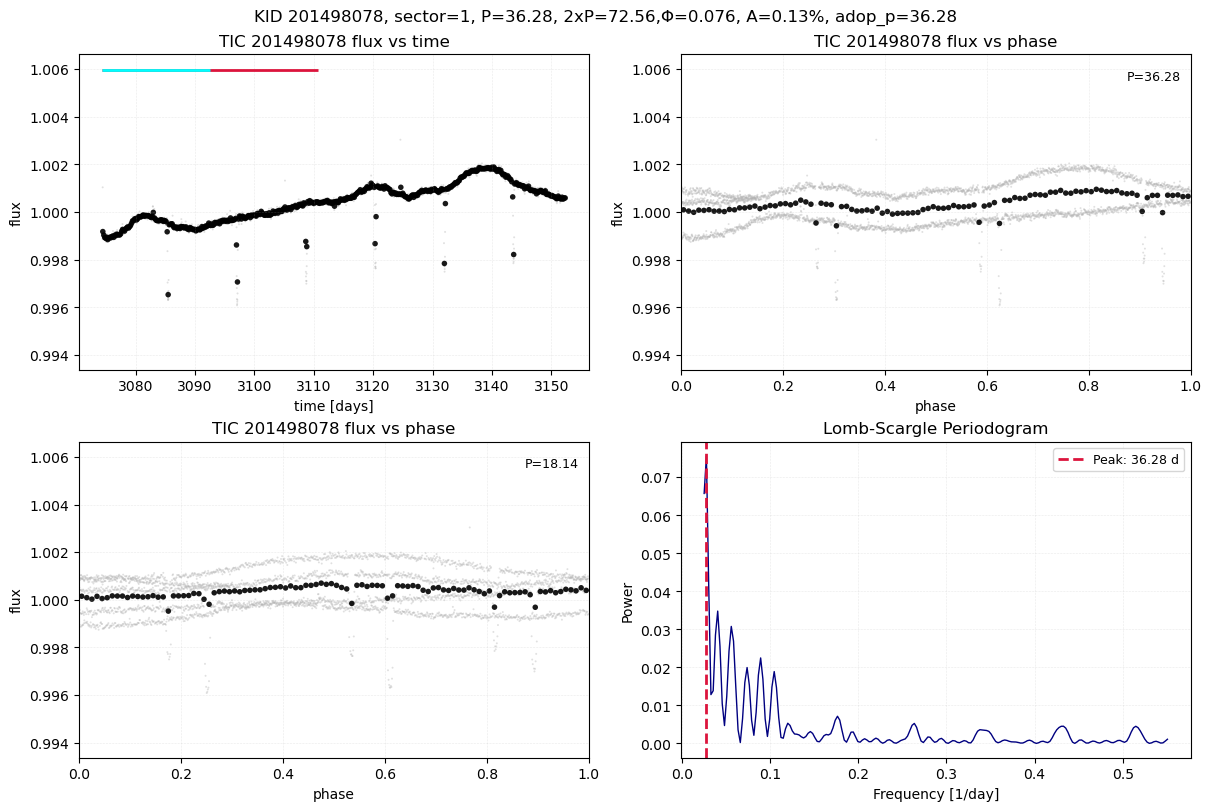

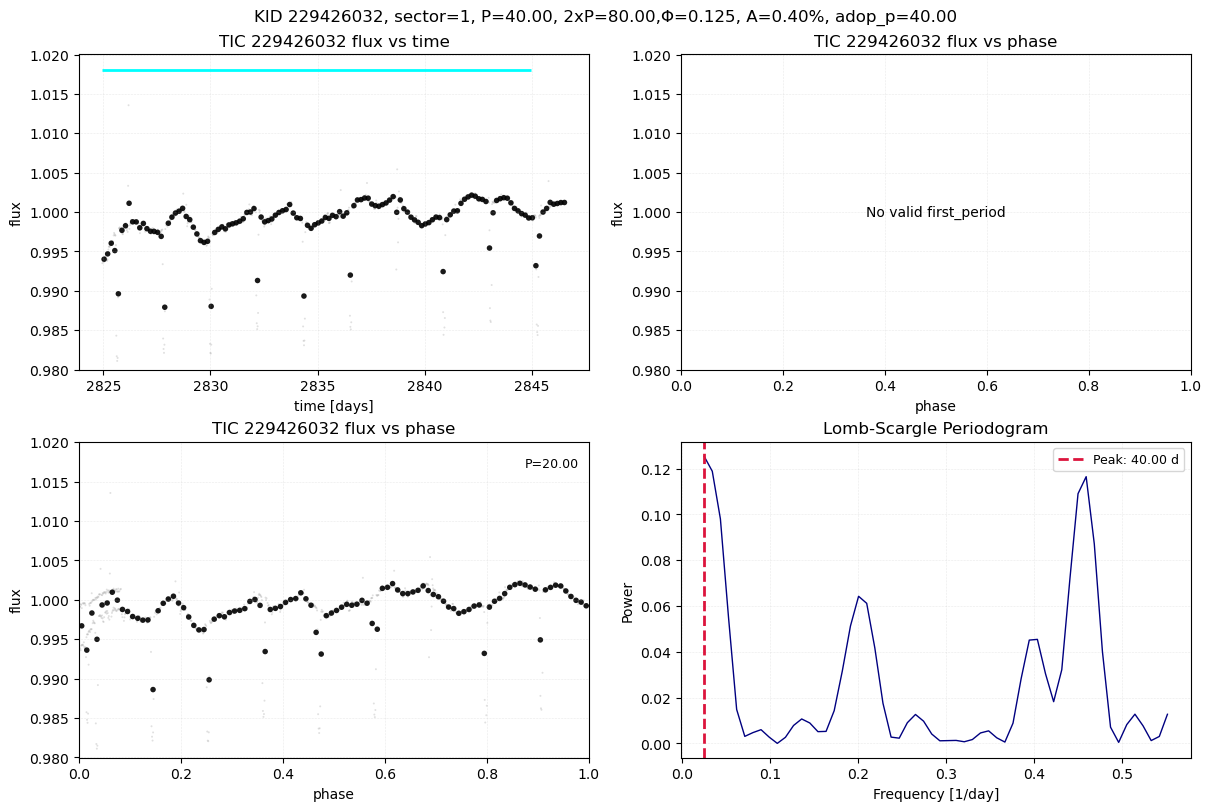

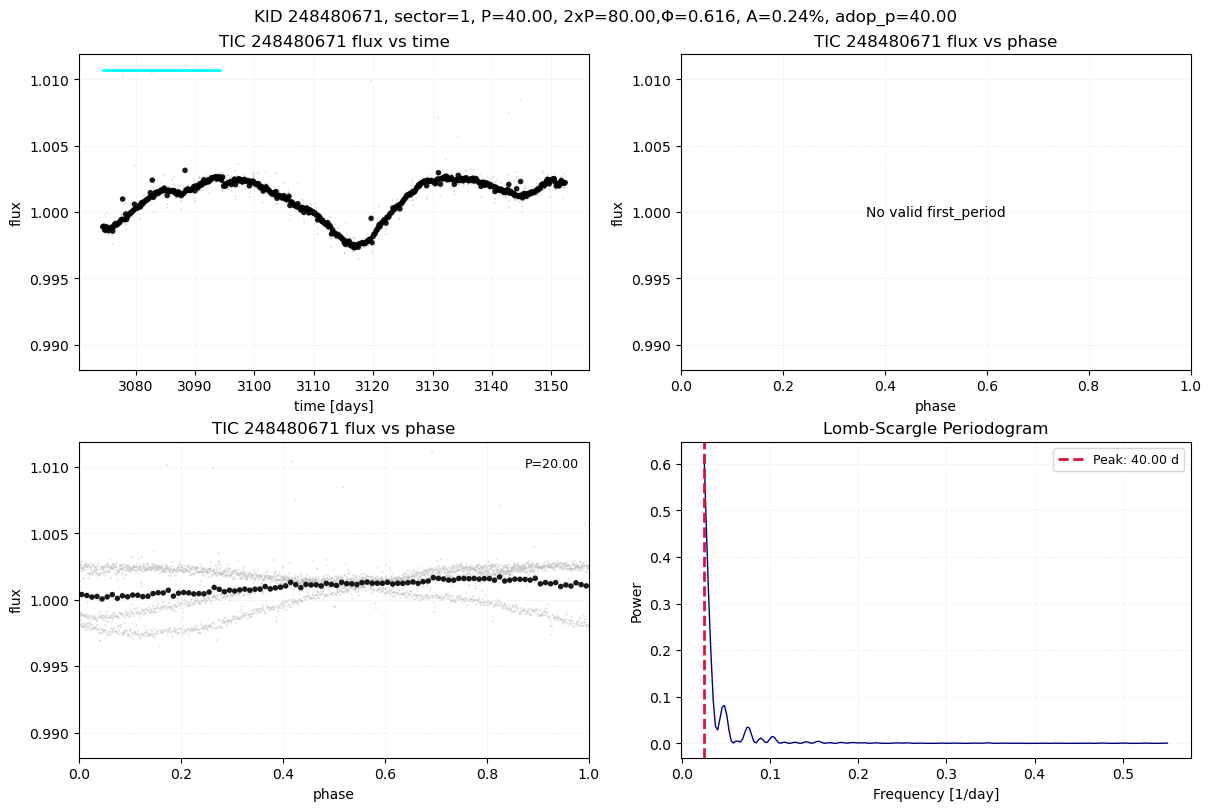

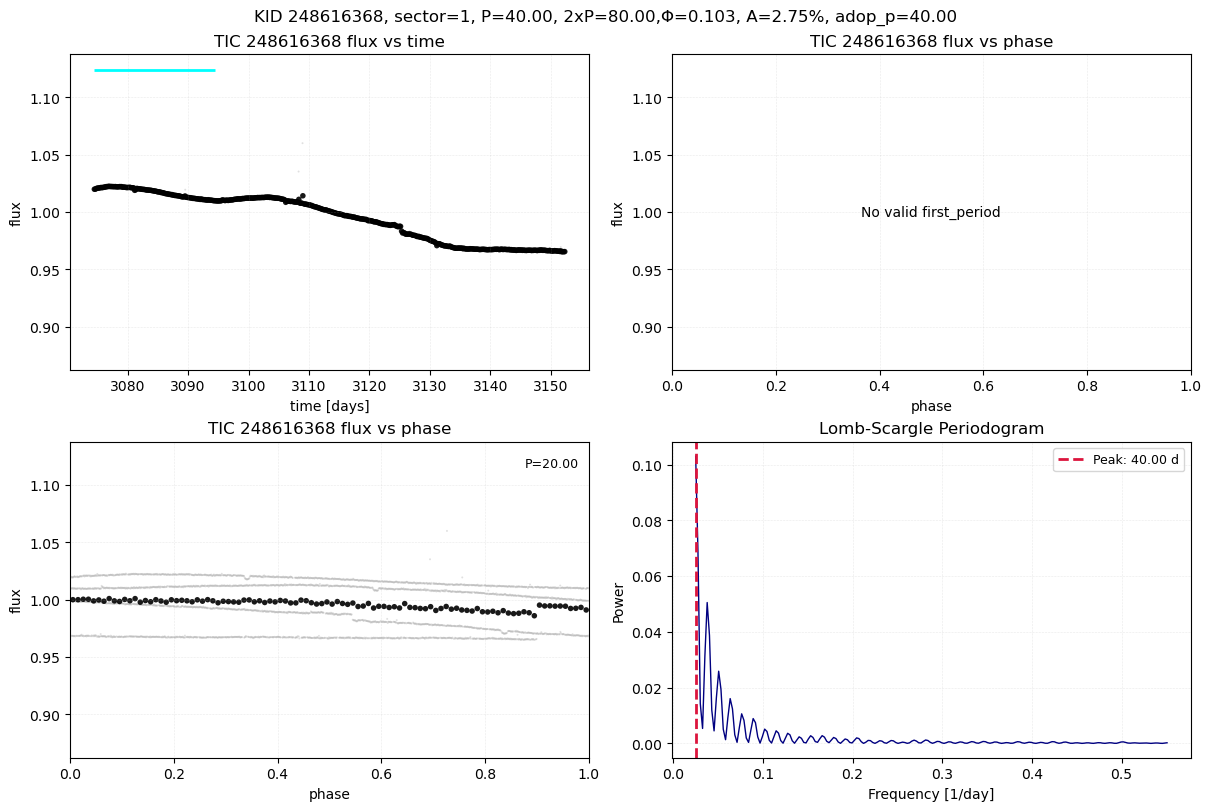

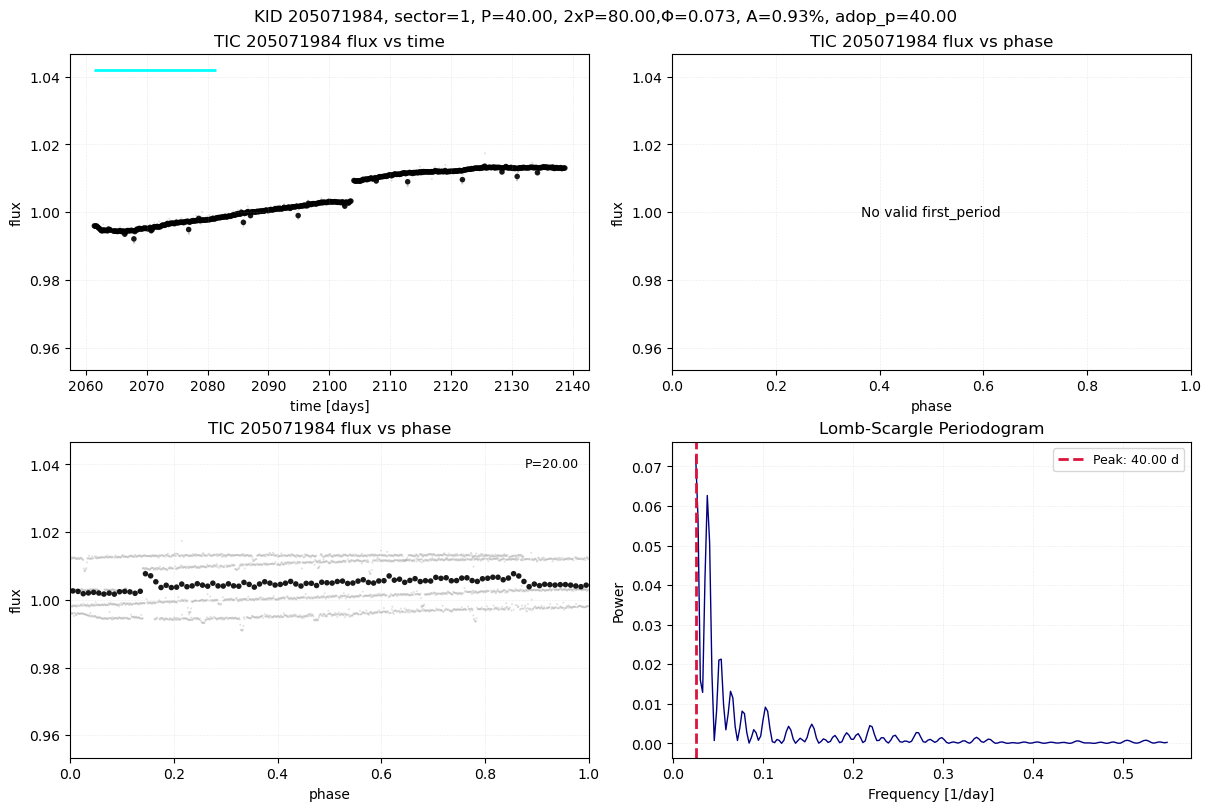

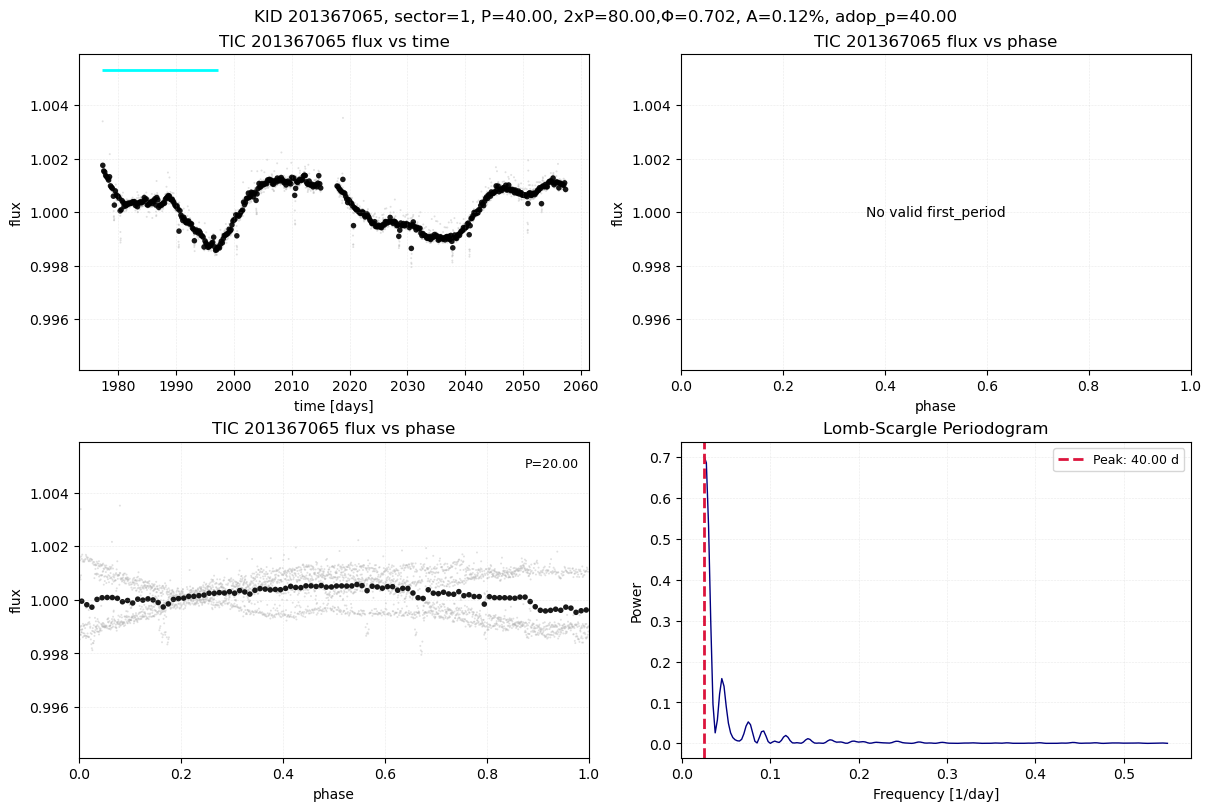

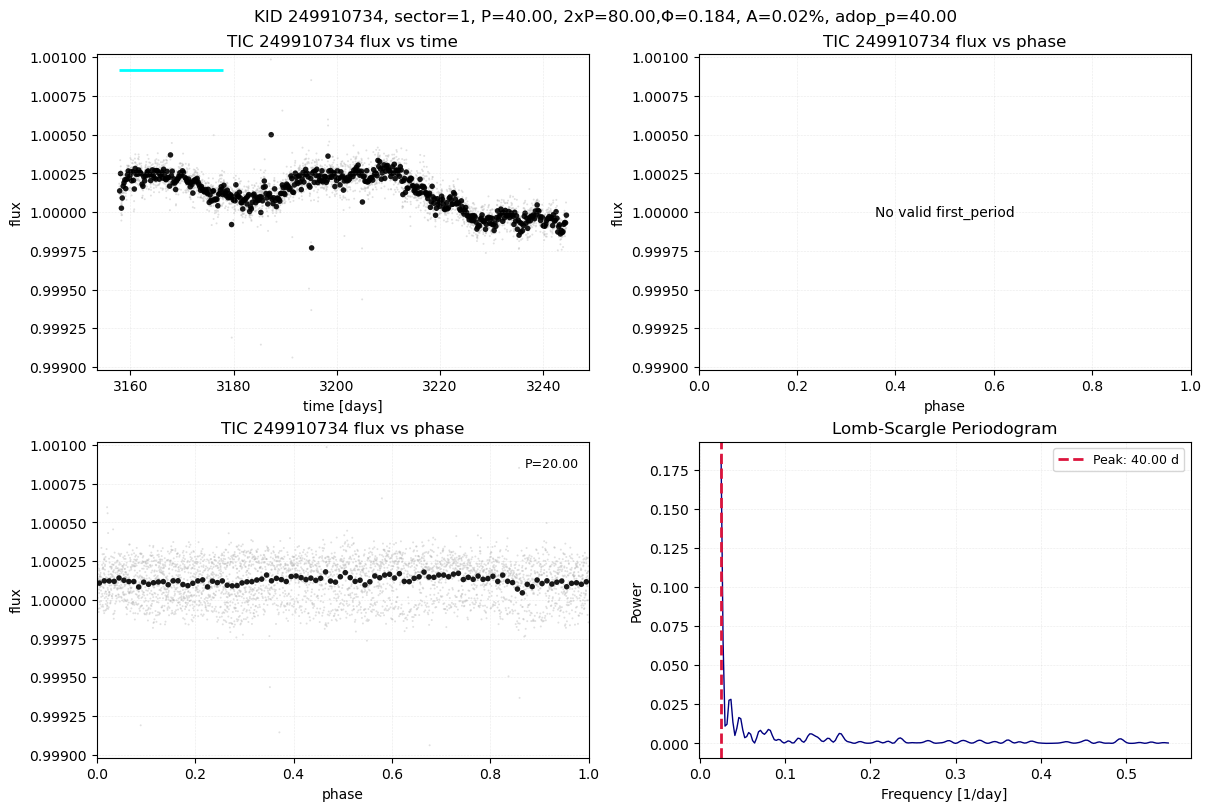

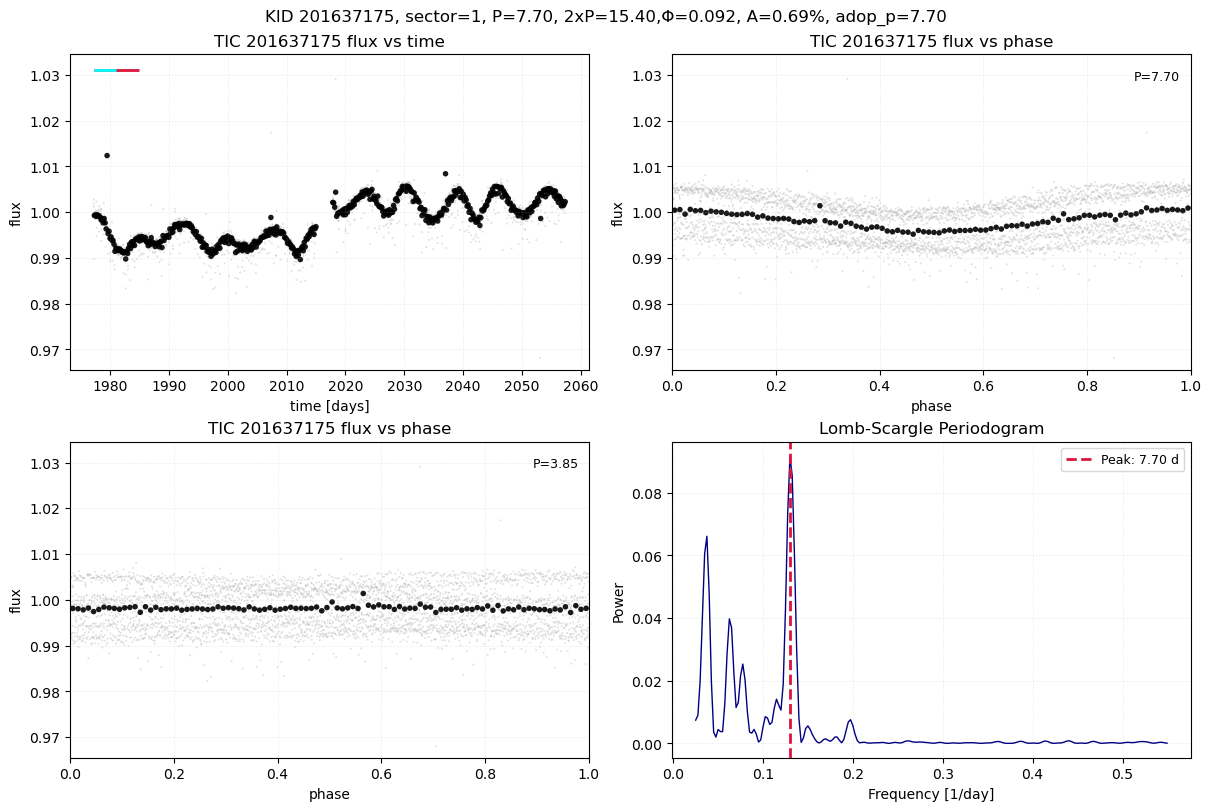

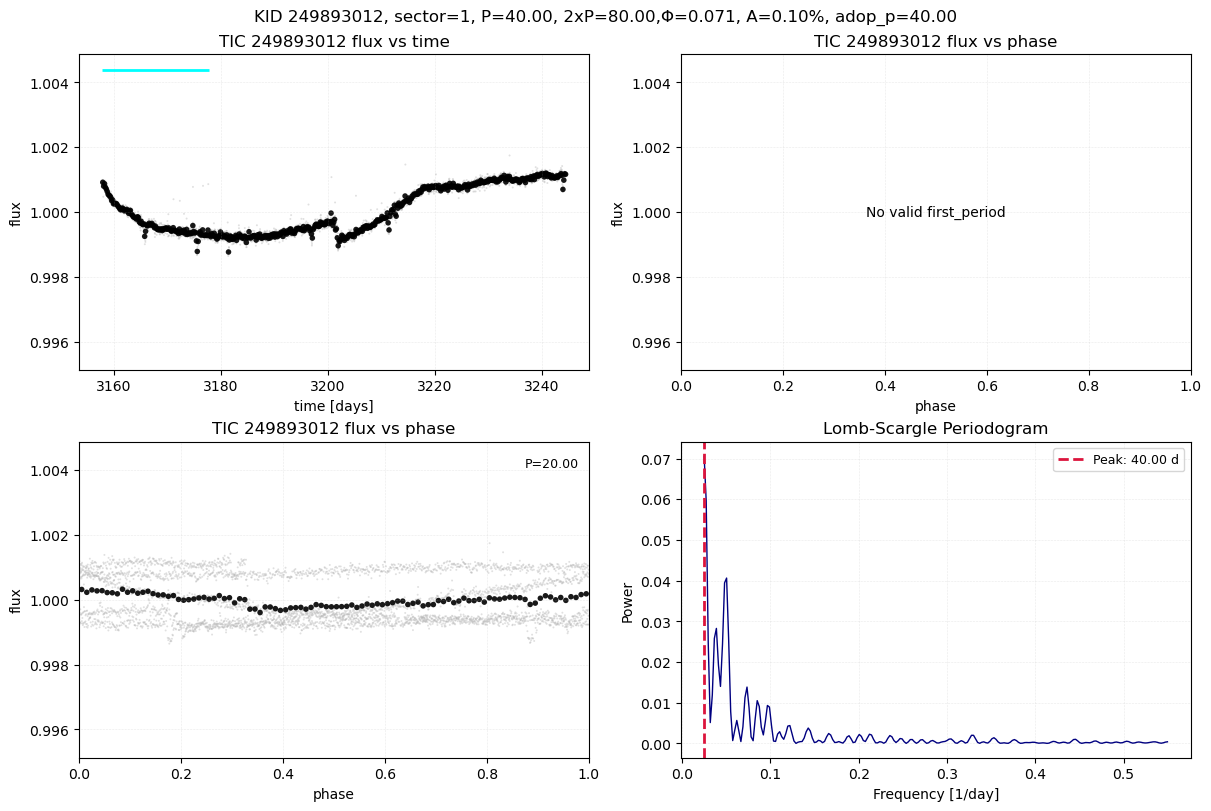

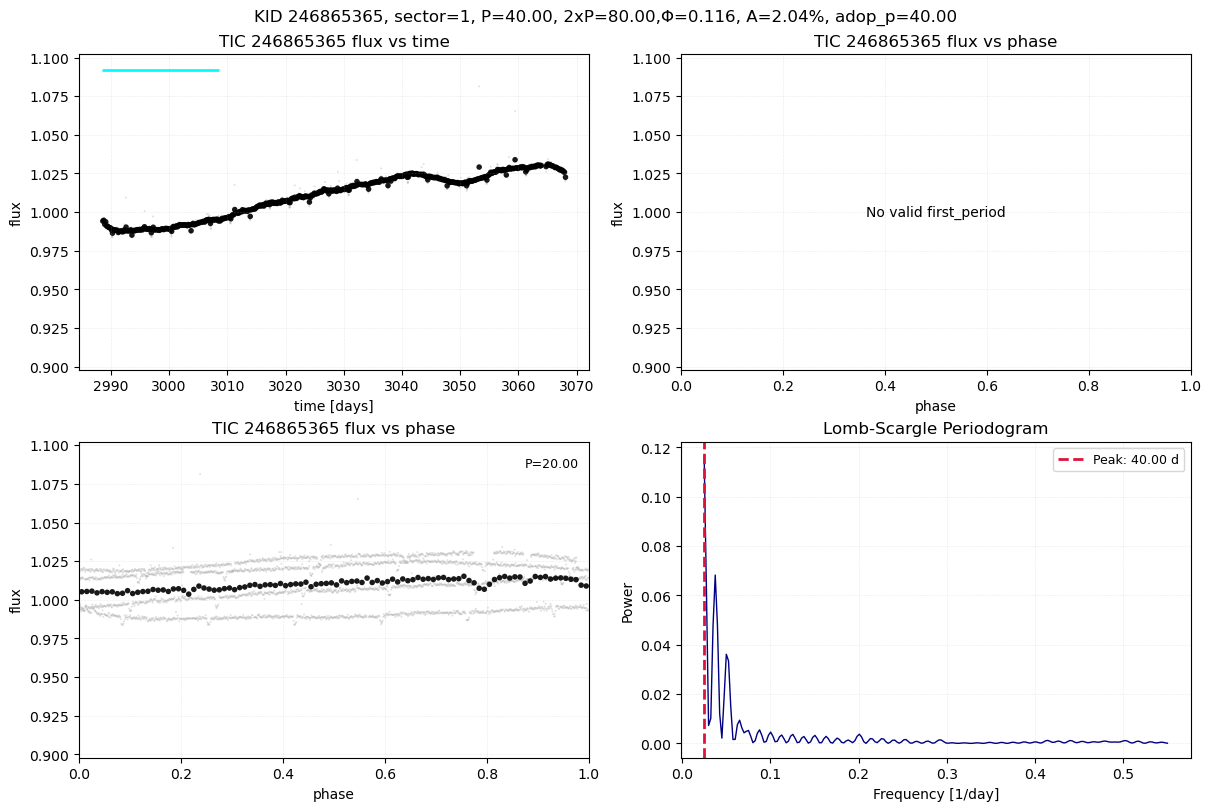

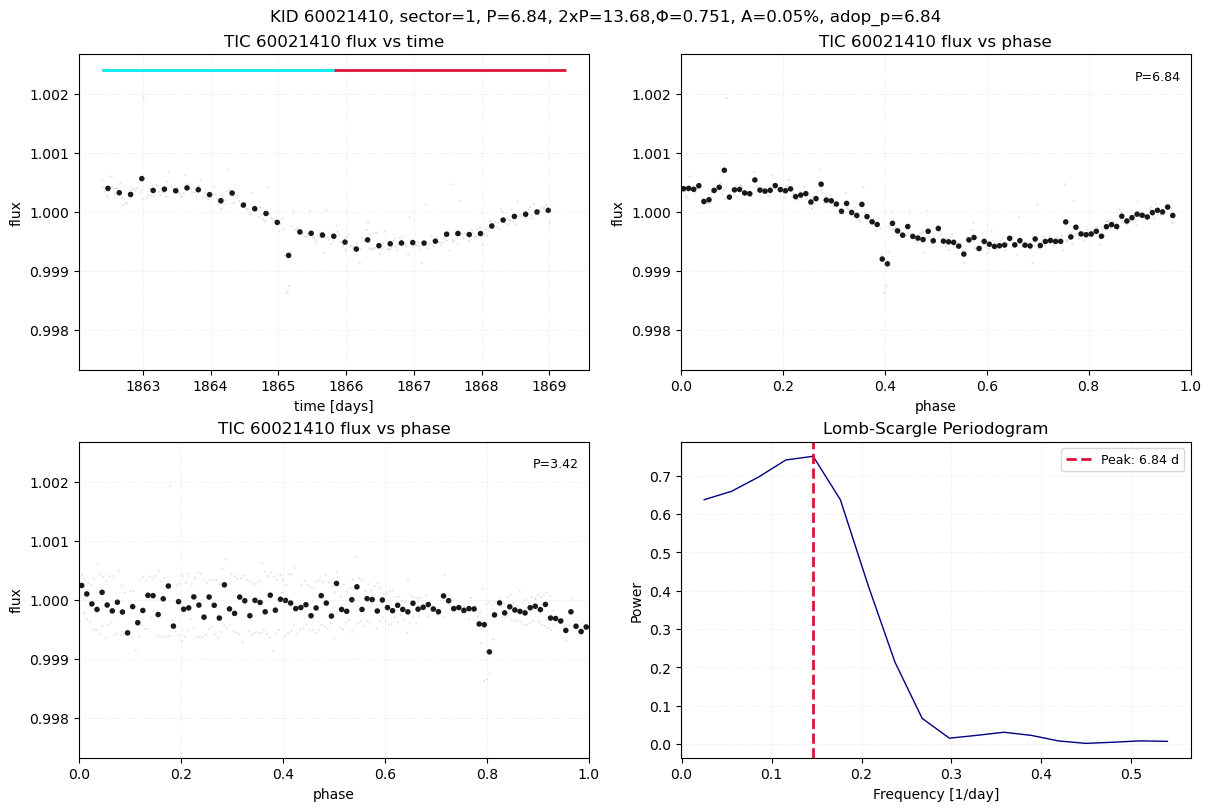

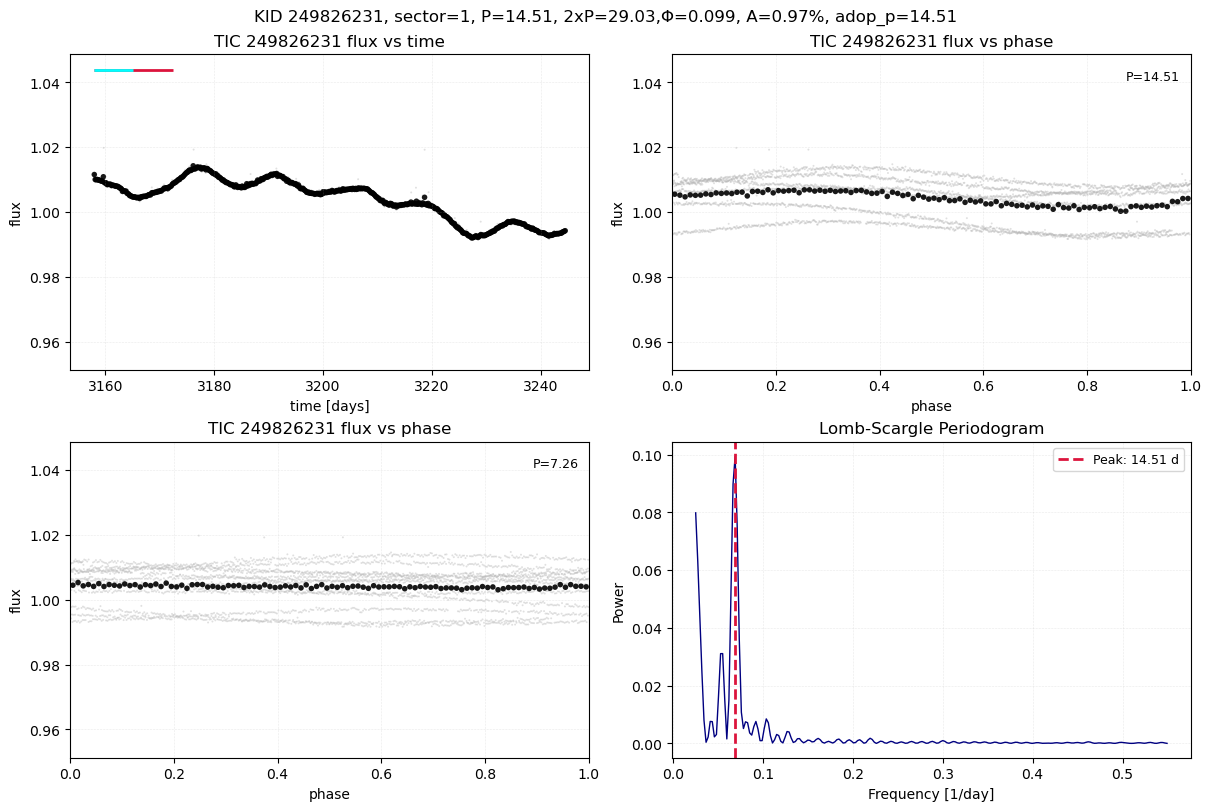

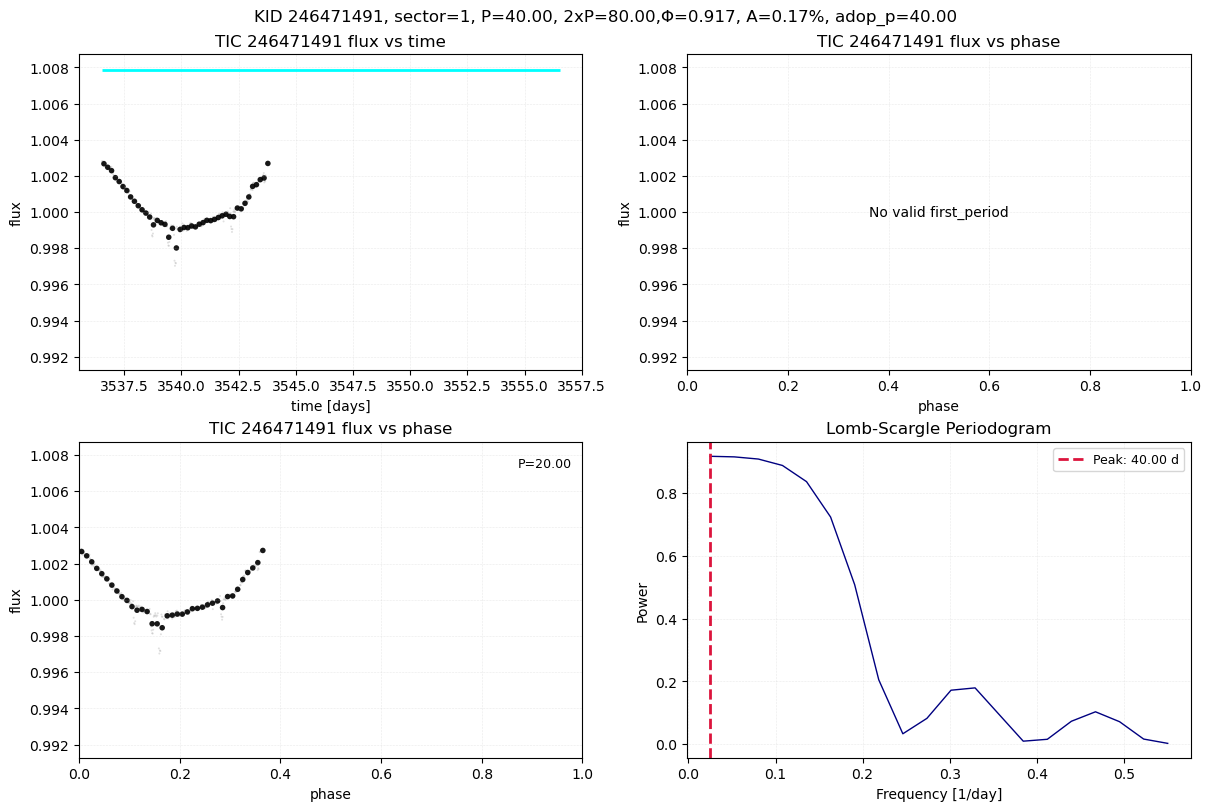

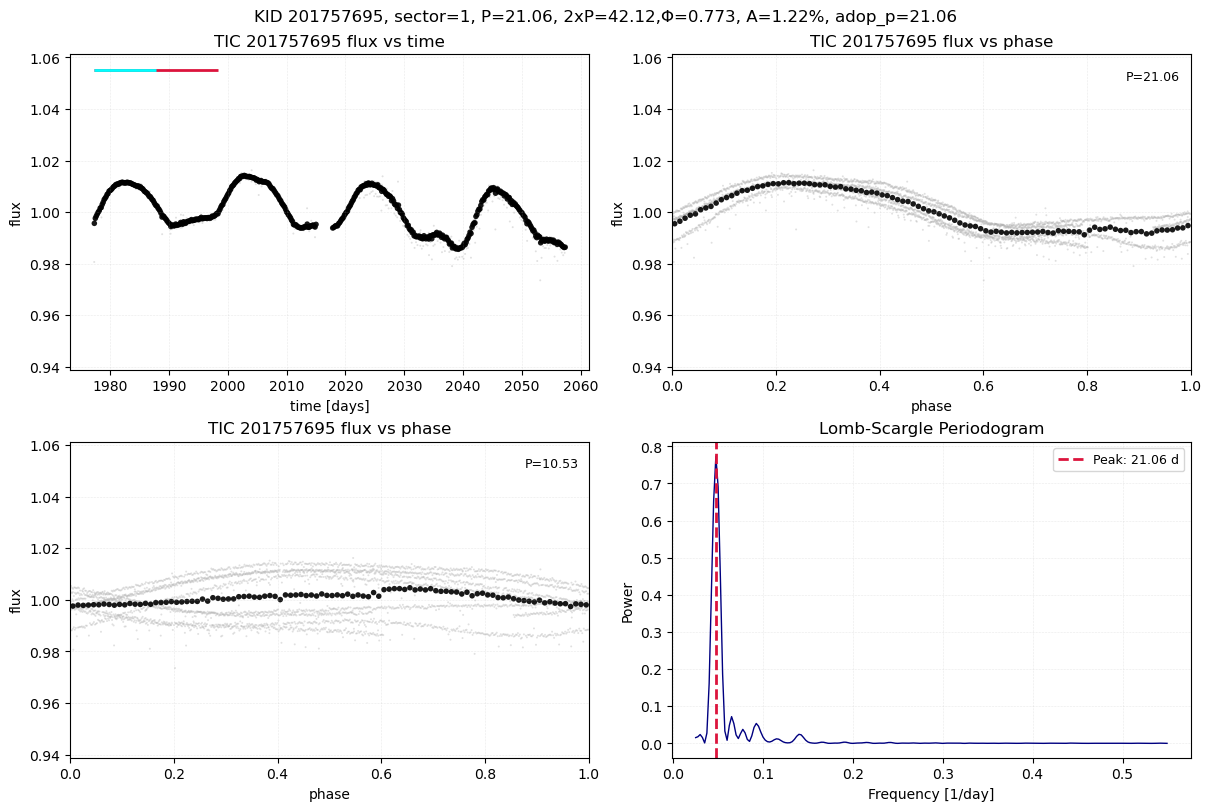

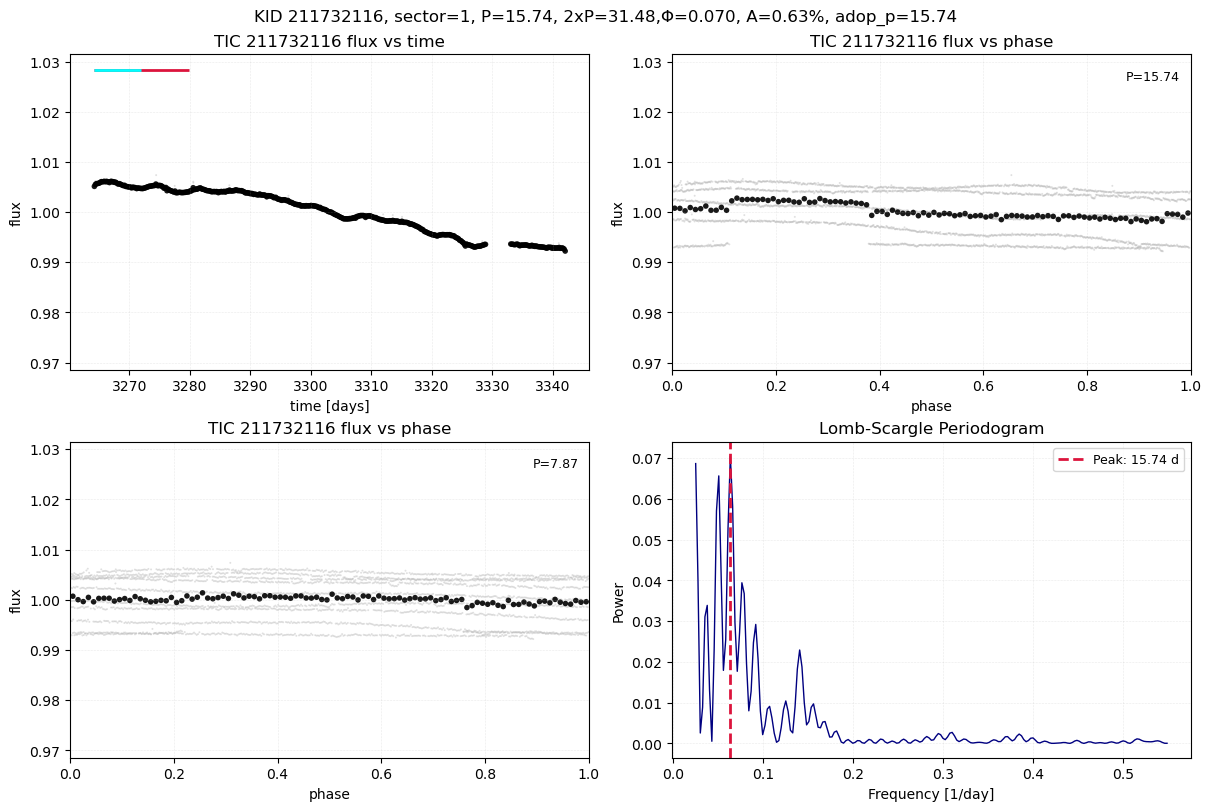

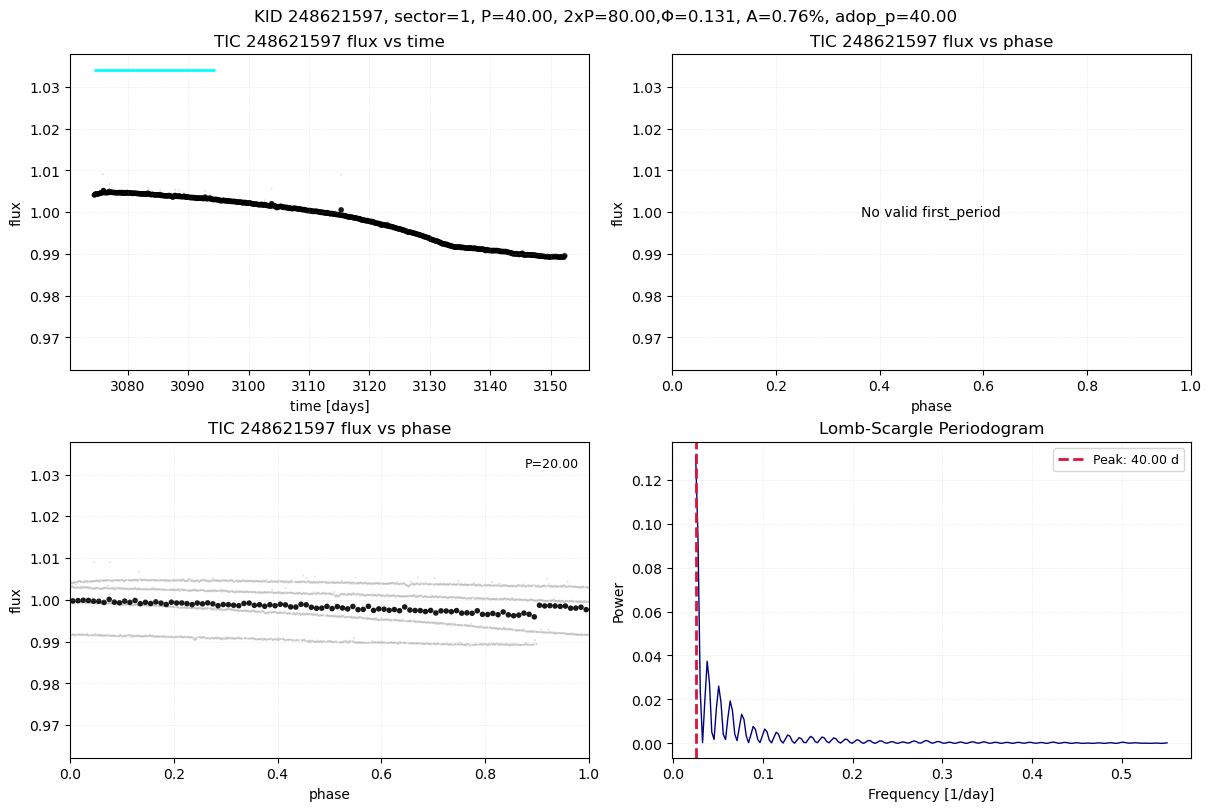

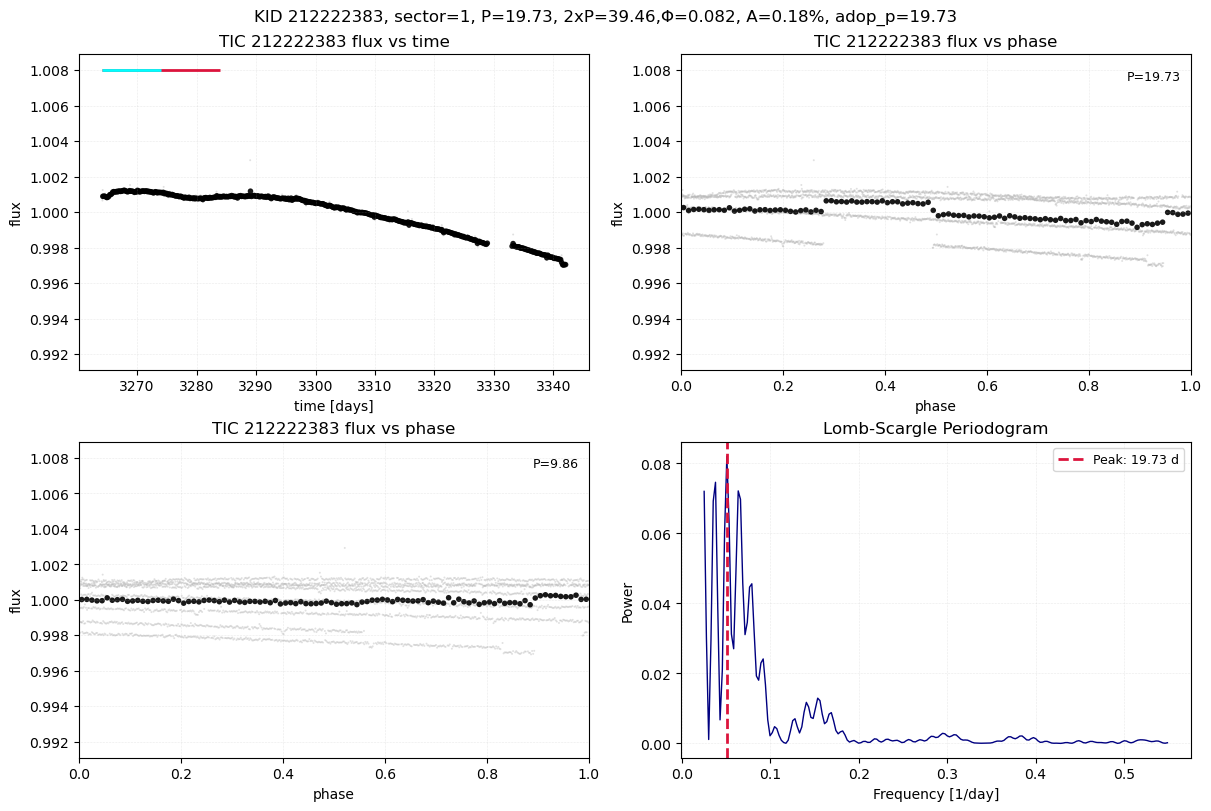

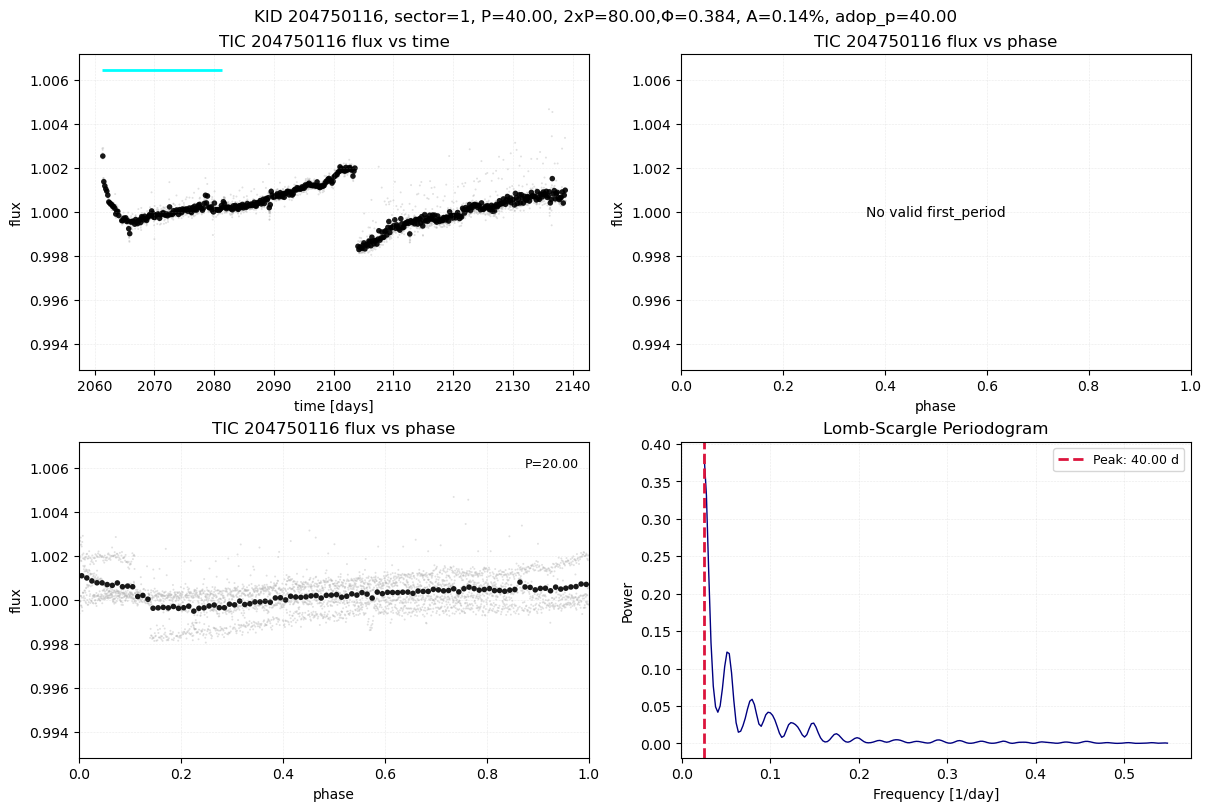

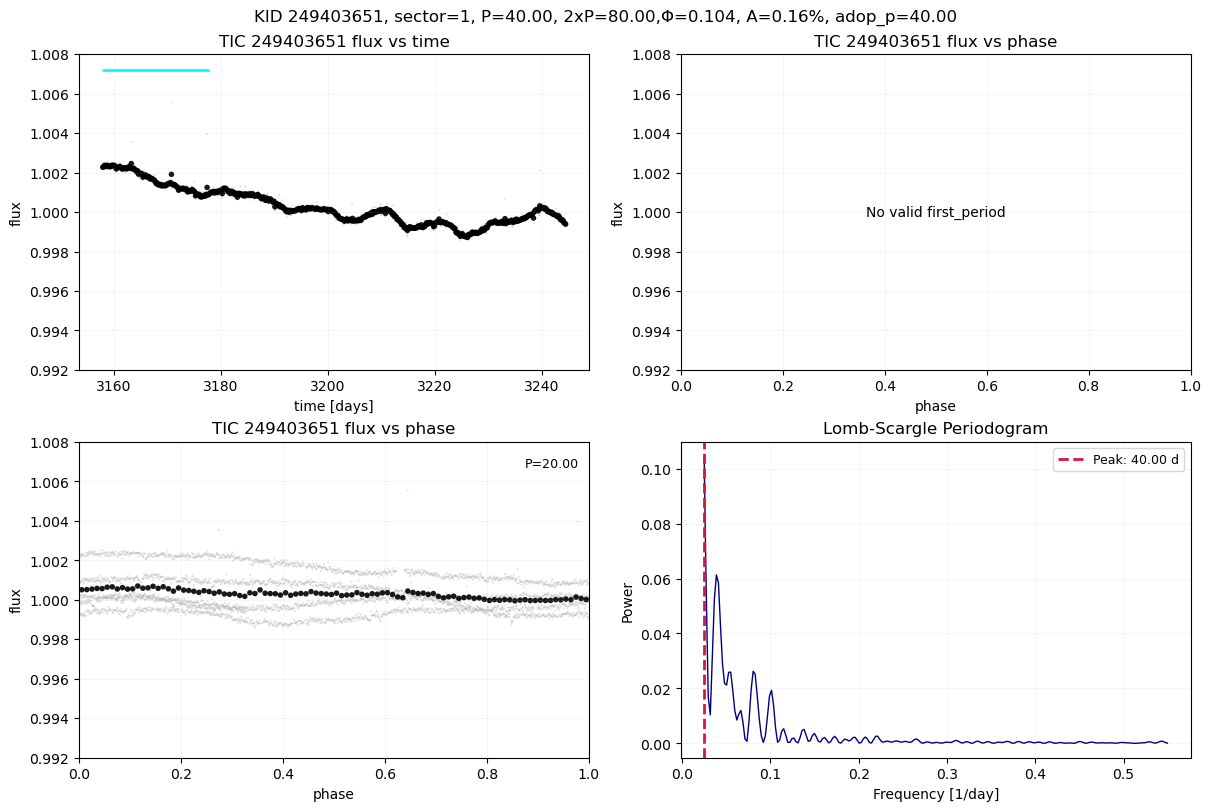

In [5]:
import matplotlib.pyplot as plt
import lightkurve as lk
from pdmpy import pdm
from tqdm import tqdm
from glob import glob
from astropy.stats import SigmaClip

file_direc = '/Users/iansterrett/k2sff/K2SFF/*/*'
kep_id_list = []
period_list = []
target_dict_list = []

for file in tqdm(glob(file_direc)):
    with fits.open(file) as hdul:
        image_data = hdul[0].header
        kid = image_data['KEPLERID']

    lc = lk.read(file)
    finite = np.isfinite(lc.flux.value)
    f = lc.flux.value[finite]

    amp = 0.5 * (np.nanpercentile(f, 95) - np.nanpercentile(f, 5))

    time, flux = lc.time.value, lc.flux.value


    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    ax_time = axes[0, 0]
    ax_phase = axes[0, 1]
    ax_two_phase = axes[1, 0]
    ax_periodogram = axes[1, 1]


    def _get_flux_ylim(best_amp_val, flux_vals):
        if np.isfinite(best_amp_val) and best_amp_val > 0:
            return (1 - 5 * best_amp_val, 1 + 5 * best_amp_val)
        finite_flux = flux_vals[np.isfinite(flux_vals)]
        if finite_flux.size:
            f_med = np.nanmedian(finite_flux)
            f_std = np.nanstd(finite_flux)
            if not np.isfinite(f_std) or f_std == 0:
                f_std = 0.1 * abs(f_med) if f_med else 1.0
            return (f_med - 5 * f_std, f_med + 5 * f_std)
        return None

    ax_time.scatter(time, flux, s=2, color="0.7", alpha=0.4, edgecolor="none", linewidths=0)
    bin_width_days = 4.0 / 24.0
    binned_time, binned_flux = _bin_series_fixed_width(time, flux, bin_width_days)
    if binned_time.size:
        ax_time.scatter(
            binned_time,
            binned_flux,
            s=16,
            color="k",
            alpha=0.9,
            edgecolor="none",
            linewidths=0,
        )
    ax_time.set_xlabel("time [days]")
    ax_time.set_ylabel("flux")
    ax_time.set_title(f"TIC {kid} flux vs time")
    ax_time.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)
    ylims_time = _get_flux_ylim(amp, flux)
    ax_time.set_ylim(ylims_time)


    frequency, power = LombScargle(time, flux).autopower(minimum_frequency = 1/40, maximum_frequency = 0.55)  # just chose frequency range manually

    # extracting the period 
    sector = 1

    max_power_index = np.argmax(power)

    max_frequency = frequency[max_power_index]

    period = 1 / max_frequency

    print("period in days = ", period)

    star_period = period
    ylims_phase = _get_flux_ylim(amp, flux)
    star_power = np.max(power)
    adopted_period = star_period

    if np.isfinite(period) and period > 0 and period < 39.999:
        star_dict = {
            'KepId':  kid,
            'Period': period,
            'MaxPowerIndex': max_power_index,
            'Amp': amp
            }
        target_dict_list.append(star_dict)
        kep_id_list.append(kid)
        period_list.append(period)
        time0 = np.nanmin(time)
        phase = np.mod(time - time0, period) / period
        ax_phase.scatter(phase, flux, s=2, color="0.7", alpha=0.4, edgecolor="none", linewidths=0)
        phase_edges = np.linspace(0, 1, 101)
        binned_phase, binned_phase_flux = _bin_series_by_edges(phase, flux, phase_edges)
        if binned_phase.size:
            ax_phase.scatter(
                binned_phase,
                binned_phase_flux,
                s=16,
                color="k",
                alpha=0.9,
                edgecolor="none",
                linewidths=0,
            )
        ax_phase.set_xlim(0, 1)
        ax_phase.text(
            0.98,
            0.95,
            f"P={period:.2f}",
            transform=ax_phase.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            color="k",
        )
        if ylims_phase:
            ax_phase.set_ylim(ylims_phase)
        if ylims_time:
            y_line = ylims_time[1] - 0.05 * (ylims_time[1] - ylims_time[0])
        else:
            y_line = ax_time.get_ylim()[1]
        x_start = np.nanmin(time)
        x_end = x_start + period
        ax_time.hlines(y_line, x_start, x_end, colors="crimson", linewidth=2, zorder=5)
    else:
        ax_phase.text(
            0.5,
            0.5,
            "No valid first_period",
            ha="center",
            va="center",
            transform=ax_phase.transAxes,
        )
        if ylims_phase:
            ax_phase.set_ylim(ylims_phase)
    ax_phase.set_xlabel("phase")
    ax_phase.set_ylabel("flux")
    ax_phase.set_title(f"TIC {kid} flux vs phase")
    ax_phase.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)

    period = 0.5*star_period
    ylims_phase = _get_flux_ylim(amp, flux)
    if np.isfinite(period) and period > 0:
        time0 = np.nanmin(time)
        phase = np.mod(time - time0, period) / period
        ax_two_phase.scatter(phase, flux, s=2, color="0.7", alpha=0.4, edgecolor="none", linewidths=0)
        phase_edges = np.linspace(0, 1, 101)
        binned_phase, binned_phase_flux = _bin_series_by_edges(phase, flux, phase_edges)
        if binned_phase.size:
            ax_two_phase.scatter(
                binned_phase,
                binned_phase_flux,
                s=16,
                color="k",
                alpha=0.9,
                edgecolor="none",
                linewidths=0,
            )
        ax_two_phase.set_xlim(0, 1)
        ax_two_phase.text(
            0.98,
            0.95,
            f"P={period:.2f}",
            transform=ax_two_phase.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            color="k",
        )
        if ylims_phase:
            ax_two_phase.set_ylim(ylims_phase)
        if ylims_time:
            y_line = ylims_time[1] - 0.05 * (ylims_time[1] - ylims_time[0])
        else:
            y_line = ax_time.get_ylim()[1]

        x_start = np.nanmin(time)
        x_end = x_start + period
        ax_time.hlines(y_line, x_start, x_end, colors="cyan", linewidth=2, zorder=10)
        #ax_time.hlines(y_line, x_start, x_end, colors="", linewidth=2)
    else:
        ax_two_phase.text(
            0.5,
            0.5,
            "No valid first_period",
            ha="center",
            va="center",
            transform=ax_two_phase.transAxes,
        )
        if ylims_phase:
            ax_two_phase.set_ylim(ylims_phase)
    ax_two_phase.set_xlabel("phase")
    ax_two_phase.set_ylabel("flux")
    ax_two_phase.set_title(f"TIC {kid} flux vs phase")
    ax_two_phase.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)


    ####
        
    # ax_zoom.scatter(time, flux, s=2, color="0.7", alpha=1, edgecolor="none")
    # bin_width_days = 4.0 / 24.0
    # binned_time, binned_flux = _bin_series_fixed_width(time, flux, bin_width_days)
    # if binned_time.size:
    #     ax_zoom.scatter(
    #         binned_time,
    #         binned_flux,
    #         s=16,
    #         color="k",
    #         alpha=0.9,
    #         edgecolor="none",
    #         linewidths=0,
    #     )
    # ax_zoom.set_xlabel("time [days]")
    # ax_zoom.set_ylabel("flux")
    # ax_zoom.set_title(f"TIC {kid} flux vs time")
    # ax_zoom.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)
    # ylims_time = _get_flux_ylim(amp, flux)
    # ax_zoom.set_ylim(ylims_time)
    # ax_zoom.set_xlim(time[0], time[0] + 1)

    # x_end = np.nanmax(time[0] + 1)
    # x_start = x_end - 2*star_period
    # ax_zoom.hlines(y_line, x_start, x_end, colors="cyan", linewidth=2)

    # x_start = np.nanmax(time[0])
    # x_end = x_start + star_period
    # ax_zoom.hlines(y_line, x_start, x_end, colors="crimson", linewidth=2)

    ax_periodogram.plot(frequency, power, color='navy', linewidth=1)
    ax_periodogram.axvline(max_frequency, color='crimson', linestyle='--', linewidth=2, label=f'Peak: {adopted_period:.2f} d')
    ax_periodogram.set_xlabel("Frequency [1/day]")
    ax_periodogram.set_ylabel("Power")
    ax_periodogram.set_title("Lomb-Scargle Periodogram")
    ax_periodogram.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)
    ax_periodogram.legend(loc='best', fontsize=9)


    fig.suptitle(
        f"KID {kid}, sector={sector}, P={star_period:.2f}, 2xP={2*star_period:.2f},Φ={star_power:.3f}, A={amp * 100:.2f}%, adop_p={adopted_period:.2f}",
        fontsize=12,
    )

    #plt.savefig(figure, dpi=300, bbox_inches='tight')

    #plt.close()

In [27]:
print(period_list)
print(len(period_list))
print(kep_id_list)
print(len(kep_id_list))

[20.009035818047284, 28.578798469770707, 33.33835431235352, 22.231140321528937, 10.006777753185402, 8.005792947516571, 26.674688825901615, 21.061636497406166, 36.36661946747376]
9
[201505350, 201338508, 201465501, 201345483, 201205469, 201384232, 201393098, 201460826, 201445392]
9


In [5]:
import matplotlib.pyplot as plt
import lightkurve as lk
from pdmpy import pdm
from tqdm import tqdm
from glob import glob
from astropy.stats import SigmaClip
import os
from pathlib import Path

file_direc = '/Users/iansterrett/k2sff/K2SFF/*/*'
kep_id_list = []
period_list = []
target_dict_list = []
out_dir = Path('/Users/iansterrett/k2sff/k2sfflightcurve')   # or Path.cwd() / "k2sfflightcurve"
out_dir.mkdir(parents=True, exist_ok=True)

for file in tqdm(glob(file_direc)):
    with fits.open(file) as hdul:
        image_data = hdul[0].header
        kid = image_data['KEPLERID']

    lc = lk.read(file)
    finite = np.isfinite(lc.flux.value)
    f = lc.flux.value[finite]

    amp = 0.5 * (np.nanpercentile(f, 95) - np.nanpercentile(f, 5))

    time, flux = lc.time.value, lc.flux.value
    time = np.asarray(lc.time.value, dtype=float)
    flux = np.asarray(lc.flux.value, dtype=float)

    # start with finite mask (important!)
    finite = np.isfinite(time) & np.isfinite(flux)
    t0 = time[finite]
    f0 = flux[finite]

    sigclip = SigmaClip(sigma=3, maxiters=None, cenfunc='mean')  # or cenfunc='median'

    # This returns a MaskedArray with .mask telling you what got clipped
    clipped = sigclip(f0)

    good = ~clipped.mask          # True where NOT clipped
    time_clean = t0[good]
    flux_clean = f0[good]
    p =  np.polyfit(time_clean, flux_clean, 3)
    fit_flux = np.polyval(p, time_clean)
    reduced_flux = flux_clean/fit_flux
    time = time_clean
    flux = reduced_flux

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    ax_time = axes[0, 0]
    ax_phase = axes[0, 1]
    ax_two_phase = axes[1, 0]
    ax_periodogram = axes[1, 1]


    def _get_flux_ylim(best_amp_val, flux_vals):
        if np.isfinite(best_amp_val) and best_amp_val > 0:
            return (1 - 5 * best_amp_val, 1 + 5 * best_amp_val)
        finite_flux = flux_vals[np.isfinite(flux_vals)]
        if finite_flux.size:
            f_med = np.nanmedian(finite_flux)
            f_std = np.nanstd(finite_flux)
            if not np.isfinite(f_std) or f_std == 0:
                f_std = 0.1 * abs(f_med) if f_med else 1.0
            return (f_med - 5 * f_std, f_med + 5 * f_std)
        return None

    ax_time.scatter(time, flux, s=2, color="0.7", alpha=0.4, edgecolor="none", linewidths=0)
    bin_width_days = 4.0 / 24.0
    binned_time, binned_flux = _bin_series_fixed_width(time, flux, bin_width_days)
    if binned_time.size:
        ax_time.scatter(
            binned_time,
            binned_flux,
            s=16,
            color="k",
            alpha=0.9,
            edgecolor="none",
            linewidths=0,
        )
    ax_time.set_xlabel("time [days]")
    ax_time.set_ylabel("flux")
    ax_time.set_title(f"TIC {kid} flux vs time")
    ax_time.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)
    ylims_time = _get_flux_ylim(amp, flux)
    ax_time.set_ylim(ylims_time)


    frequency, power = LombScargle(time, flux).autopower(minimum_frequency = 1/40, maximum_frequency = 0.55)  # just chose frequency range manually

    # extracting the period 
    sector = 1

    max_power_index = np.argmax(power)

    max_frequency = frequency[max_power_index]

    period = 1 / max_frequency

    print("period in days = ", period)

    star_period = period
    ylims_phase = _get_flux_ylim(amp, flux)
    star_power = np.max(power)
    adopted_period = star_period

    if np.isfinite(period) and period > 0 and period < 39.999:
        star_dict = {
        'KepId':  kid,
        'Period': period,
        'MaxPowerIndex': max_power_index,
        'Amp': amp
        }
        target_dict_list.append(star_dict)
        kep_id_list.append(kid)
        period_list.append(period)
        time0 = np.nanmin(time)
        phase = np.mod(time - time0, period) / period
        ax_phase.scatter(phase, flux, s=2, color="0.7", alpha=0.4, edgecolor="none", linewidths=0)
        phase_edges = np.linspace(0, 1, 101)
        binned_phase, binned_phase_flux = _bin_series_by_edges(phase, flux, phase_edges)
        if binned_phase.size:
            ax_phase.scatter(
                binned_phase,
                binned_phase_flux,
                s=16,
                color="k",
                alpha=0.9,
                edgecolor="none",
                linewidths=0,
            )
        ax_phase.set_xlim(0, 1)
        ax_phase.text(
            0.98,
            0.95,
            f"P={period:.2f}",
            transform=ax_phase.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            color="k",
        )
        if ylims_phase:
            ax_phase.set_ylim(ylims_phase)
        if ylims_time:
            y_line = ylims_time[1] - 0.05 * (ylims_time[1] - ylims_time[0])
        else:
            y_line = ax_time.get_ylim()[1]
        x_start = np.nanmin(time)
        x_end = x_start + period
        ax_time.hlines(y_line, x_start, x_end, colors="crimson", linewidth=2, zorder=5)
    else:
        ax_phase.text(
            0.5,
            0.5,
            "No valid first_period",
            ha="center",
            va="center",
            transform=ax_phase.transAxes,
        )
        if ylims_phase:
            ax_phase.set_ylim(ylims_phase)
    ax_phase.set_xlabel("phase")
    ax_phase.set_ylabel("flux")
    ax_phase.set_title(f"TIC {kid} flux vs phase")
    ax_phase.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)

    period = 0.5*star_period
    ylims_phase = _get_flux_ylim(amp, flux)
    if np.isfinite(period) and period > 0:
        time0 = np.nanmin(time)
        phase = np.mod(time - time0, period) / period
        ax_two_phase.scatter(phase, flux, s=2, color="0.7", alpha=0.4, edgecolor="none", linewidths=0)
        phase_edges = np.linspace(0, 1, 101)
        binned_phase, binned_phase_flux = _bin_series_by_edges(phase, flux, phase_edges)
        if binned_phase.size:
            ax_two_phase.scatter(
                binned_phase,
                binned_phase_flux,
                s=16,
                color="k",
                alpha=0.9,
                edgecolor="none",
                linewidths=0,
            )
        ax_two_phase.set_xlim(0, 1)
        ax_two_phase.text(
            0.98,
            0.95,
            f"P={period:.2f}",
            transform=ax_two_phase.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            color="k",
        )
        if ylims_phase:
            ax_two_phase.set_ylim(ylims_phase)
        if ylims_time:
            y_line = ylims_time[1] - 0.05 * (ylims_time[1] - ylims_time[0])
        else:
            y_line = ax_time.get_ylim()[1]

        x_start = np.nanmin(time)
        x_end = x_start + period
        ax_time.hlines(y_line, x_start, x_end, colors="cyan", linewidth=2, zorder=10)
        #ax_time.hlines(y_line, x_start, x_end, colors="", linewidth=2)
    else:
        ax_two_phase.text(
            0.5,
            0.5,
            "No valid first_period",
            ha="center",
            va="center",
            transform=ax_two_phase.transAxes,
        )
        if ylims_phase:
            ax_two_phase.set_ylim(ylims_phase)
    ax_two_phase.set_xlabel("phase")
    ax_two_phase.set_ylabel("flux")
    ax_two_phase.set_title(f"TIC {kid} flux vs phase")
    ax_two_phase.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)


    ####
        
    # ax_zoom.scatter(time, flux, s=2, color="0.7", alpha=1, edgecolor="none")
    # bin_width_days = 4.0 / 24.0
    # binned_time, binned_flux = _bin_series_fixed_width(time, flux, bin_width_days)
    # if binned_time.size:
    #     ax_zoom.scatter(
    #         binned_time,
    #         binned_flux,
    #         s=16,
    #         color="k",
    #         alpha=0.9,
    #         edgecolor="none",
    #         linewidths=0,
    #     )
    # ax_zoom.set_xlabel("time [days]")
    # ax_zoom.set_ylabel("flux")
    # ax_zoom.set_title(f"TIC {kid} flux vs time")
    # ax_zoom.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)
    # ylims_time = _get_flux_ylim(amp, flux)
    # ax_zoom.set_ylim(ylims_time)
    # ax_zoom.set_xlim(time[0], time[0] + 1)

    # x_end = np.nanmax(time[0] + 1)
    # x_start = x_end - 2*star_period
    # ax_zoom.hlines(y_line, x_start, x_end, colors="cyan", linewidth=2)

    # x_start = np.nanmax(time[0])
    # x_end = x_start + star_period
    # ax_zoom.hlines(y_line, x_start, x_end, colors="crimson", linewidth=2)

    ax_periodogram.plot(frequency, power, color='navy', linewidth=1)
    ax_periodogram.axvline(max_frequency, color='crimson', linestyle='--', linewidth=2, label=f'Peak: {adopted_period:.2f} d')
    ax_periodogram.set_xlabel("Frequency [1/day]")
    ax_periodogram.set_ylabel("Power")
    ax_periodogram.set_title("Lomb-Scargle Periodogram")
    ax_periodogram.grid(True, which="both", ls=":", lw=0.4, alpha=0.5)
    ax_periodogram.legend(loc='best', fontsize=9)


    fig.suptitle(
        f"KID {kid}, sector={sector}, P={star_period:.2f}, 2xP={2*star_period:.2f},Φ={star_power:.3f}, A={amp * 100:.2f}%, adop_p={adopted_period:.2f}",
        fontsize=12,
    )

    # safe filename: include Kepler ID and period
    filename = f"KID_{kid}_P{star_period:.3f}.png"
    save_path = out_dir / filename

    # save and close to free memory
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close(fig)

  0%|          | 0/162 [00:00<?, ?it/s]

period in days =  15.39316474523178


  1%|          | 1/162 [00:00<01:50,  1.46it/s]

period in days =  3.3171079770779954


  1%|          | 2/162 [00:01<01:31,  1.74it/s]

...

 99%|█████████▉| 160/162 [01:30<00:01,  1.63it/s]

period in days =  23.26596684147986


 99%|█████████▉| 161/162 [01:31<00:00,  1.72it/s]

period in days =  1.9082113904939113


100%|██████████| 162/162 [01:31<00:00,  1.77it/s]


In [5]:
print(target_dict_list)

[{'KepId': 201613023, 'Period': 15.39316474523178, 'MaxPowerIndex': 16, 'Amp': 0.002193383863504983}, {'KepId': 246220667, 'Period': 3.3171079770779954, 'MaxPowerIndex': 10, 'Amp': 0.0035235660268316815}, {'KepId': 247383003, 'Period': 33.30560371541266, 'MaxPowerIndex': 2, 'Amp': 0.010039267544212915}, {'KepId': 249889081, 'Period': 29.202793259082856, 'MaxPowerIndex': 4, 'Amp': 0.003957290862191154}, {'KepId': 212048748, 'Period': 33.18126989920222, 'MaxPowerIndex': 2, 'Amp': 0.01024792342138725}, {'KepId': 248558190, 'Period': 7.999038822169806, 'MaxPowerIndex': 39, 'Amp': 0.00531313400241451}, {'KepId': 229426032, 'Period': 26.604744607711538, 'MaxPowerIndex': 3, 'Amp': 0.006426208552202828}, {'KepId': 201736247, 'Period': 18.19078525431521, 'MaxPowerIndex': 12, 'Amp': 0.00273584434439067}, {'KepId': 245991048, 'Period': 30.648944090406435, 'MaxPowerIndex': 3, 'Amp': 0.004612327955554385}, {'KepId': 246472939, 'Period': 23.36578381131836, 'MaxPowerIndex': 7, 'Amp': 0.01672325479140

In [4]:
import glob
import re

file_direc_plots = '/Users/iansterrett/Documents/GitHub/Astro502_sp26/rek2sff_plots/*.png'
kepler_ids = []
periods = []

for file in glob.glob(file_direc_plots):
    match = re.search(r'KID_(\d+)_P([\d.]+)\[g\]\.png', file)
    if match:
        kepler_ids.append(match.group(1))
        periods.append(float(match.group(2)))

print(kepler_ids)
print(periods)

['220241529', '210363145', '211611158', '206119924', '212480208', '220592745', '212132195', '212735333', '220696233', '212554013', '220170303', '211359660', '211990866', '212012119', '212088059', '220504338', '220481411', '211770795', '205916793', '217977895', '210838726', '211897691', '211818569', '212012119', '212499991', '211990866', '206159027', '212779596', '211913977', '211529065', '212132195', '211969807', '220522262', '212555594', '212006318', '210965800', '211916756', '211529065', '212554013', '212006344', '212686205', '212828909', '217941732', '212580872', '206026136', '214173069', '212440430', '211331236', '220194974', '211969807', '216008129', '211970147', '210750726', '220621087', '212768333', '211913977', '210968143', '212756297', '212157262', '212088059', '212828909', '211970147', '210490365', '211969807', '218916923', '211897691', '211529065', '212499991', '210818897', '211970147', '206007892', '251319382', '212072539', '211818569', '212157262', '212072539', '212460519'